# Results DR26

**Table of contents**<a id='toc0_'></a>    
- 1. [Imports](#toc1_)    
- 2. [Load Data                  ](#toc2_)    
  - 2.1. [Hyperparameters](#toc2_1_)    
- 3. [Life cycle income](#toc3_)    
- 4. [Convergence](#toc4_)    
- 5. [Life-cycle profiles](#toc5_)    
  - 5.1. [Cross-section](#toc5_1_)    
- 6. [Transfer](#toc6_)    
- 7. [Speed of Convergence                  ](#toc7_)    
  - 7.1. [With DP](#toc7_1_)    
  - 7.2. [Without DP](#toc7_2_)    
    - 7.2.1. [Backward refinement](#toc7_2_1_)    
- 8. [(Consumption) Euler Errors](#toc8_)    
- 9. [Table](#toc9_)    
  - 9.1. [DP](#toc9_1_)    
  - 9.2. [Full](#toc9_2_)    
- 10. [Policy functions](#toc10_)    
  - 10.1. [1D](#toc10_1_)    
    - 10.1.1. [Chose where to plot policy](#toc10_1_1_)    
    - 10.1.2. [Generate policies in levels](#toc10_1_2_)    
    - 10.1.3. [Plot](#toc10_1_3_)    
  - 10.2. [8D](#toc10_2_)    
    - 10.2.1. [Choose where to plot policy](#toc10_2_1_)    
    - 10.2.2. [Get policy in levels](#toc10_2_2_)    
    - 10.2.3. [Plot policy](#toc10_2_3_)    
- 11. [More on convergence](#toc11_)    
  - 11.1. [Backward](#toc11_1_)    
  - 11.2. [Softmax](#toc11_2_)    
- 12. [MPC, MPX](#toc12_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

## 1. <a id='toc1_'></a>[Imports](#toc0_)

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # without this python may crash when plotting from matplotlib
import sys

from IPython.display import display, HTML

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})
plt.rcParams.update({'font.family':'serif'})
import matplotlib.lines as mlines

from copy import deepcopy

In [3]:
import EconDLSolvers
from DurablesModel import DurablesModelClass

In [4]:
parent_directory = os.path.abspath('..')
sys.path.append(parent_directory)
from plot_funcs import load, load_all, get_train_specs_rows, train_specs, compute_transfer, transfer_plot, convergence_plot
from model_funcs import compute_d_and_c_from_action, compute_d_and_c_from_action_softmax

## 2. <a id='toc2_'></a>[Load Data](#toc2_)                   [&#8593;](#toc0_)

In [5]:
folder_load = '../output/'
folder = '../output/results'
algonames = ['DeepSimulate','DeepFOC']
Ds = [1,2,3,8]

In [6]:
algolabels = {
    'DeepSimulate':'DeepSimulate',
    'DeepFOC':'DeepFOC',
}

In [7]:
def get_model(models,algoname,D,postfix=None):

    if len(algoname.split('_')) == 2:
        key = (algoname.split('_')[0],f'{D}D',algoname.split('_')[1])
    else:
        key = (algoname,f'{D}D')
    if postfix is not None:
            key = (algoname.split('_')[0],f'{D}D',postfix)

                     
    if key in models:
        return models[key]
    else:
        return None

In [8]:
models = load_all(folder_load,'DurablesModel')

DP 1D
DP 1D fine
DP 1D rough
DP 2D
DP 2D fine
DP 2D rough
DP 3D rough
DeepFOCBackward 8D
DeepFOC 1D
DeepFOC 2D
DeepFOC 3D
DeepFOC 8D
DeepFOC 8D softmax
DeepSimulate 1D
DeepSimulate 2D
DeepSimulate 3D
DeepSimulate 8D
DeepSimulate 8D softmax


Move simulation to numpy and add variables:

In [9]:
for model in models.values():

    # a. to numpy
    for k,v in model.sim.__dict__.items():
        if isinstance(v,torch.Tensor):
            model.sim.__dict__[k] = v.numpy()

    # b. unpack states
    model.sim.m = model.sim.states[...,0]
    for k in range(model.par.D):
        model.sim.__dict__[f'd{k}'] = model.sim.states[...,k+1]

In [10]:
print(models[('DeepFOC','1D')].sim.R)
print(models[('DeepSimulate','1D')].sim.R)

-28.960346
-28.960419


In [11]:
print(models[('DeepFOC','2D')].sim.R)
print(models[('DeepSimulate','2D')].sim.R)

-32.89358
-32.89365


In [12]:
print(models[('DeepFOC','8D')].sim.R)
print(models[('DeepSimulate','8D')].sim.R)

-38.71915
-38.718155


### 2.1. <a id='toc2_1_'></a>[Hyperparameters](#toc0_)

In [13]:
do_display = False
for D in Ds:
    if do_display: print(f'D = {D}')
    models_ = {k:v for k,v in models.items() if int(k[1][0]) == D and len(k) == 2 and not k[0] == 'DP'}
    train_specs(models_,do_display=do_display,folder=folder,filename=f'DurablesModel_train_specs_{D}D')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Easier to read:

In [14]:
rows = set([k for k,l in get_train_specs_rows()])
models_ = {f'{k[0]}_{k[1]}':v for k,v in models.items() if len(k) == 2 and not k[0] == 'DP'}
print('In table:')
EconDLSolvers.figs.compare_hyperparams(models_,include=rows)
print('Not in table:')
EconDLSolvers.figs.compare_hyperparams(models_,exclude=rows)

In table:


,DeepFOCBackward_8D,DeepFOC_1D,DeepFOC_2D,DeepFOC_3D,DeepFOC_8D,DeepSimulate_1D,DeepSimulate_2D,DeepSimulate_3D,DeepSimulate_8D
Delta_epoch_policy,5,5,5,5,5,None,None,None,None
K,100000,100000,100000,100000,100000,100000,100000,100000,100000
K_time,240,120,120,120,240,120,120,120,240
N,1000000,150,150,150,150,5000,5000,5000,5000
Nepochs_policy,15,15,15,15,15,None,None,None,None
Ngpus,1,1,1,1,1,1,1,1,1
Nneurons_policy,"[1000, 1000]","[700, 700]","[700, 700]","[700, 700]","[1000, 1000]","[500, 500]","[500, 500]","[500, 500]","[500, 500]"
batch_size,100000,150,150,150,150,None,None,None,None
buffer_memory,8,8,8,8,8,1,1,1,1
clip_grad_policy,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


Not in table:


,DeepFOCBackward_8D,DeepFOC_1D,DeepFOC_2D,DeepFOC_3D,DeepFOC_8D,DeepSimulate_1D,DeepSimulate_2D,DeepSimulate_3D,DeepSimulate_8D
Delta_epoch_value,None,None,None,None,None,None,None,None,None
Delta_time,20,20,20,20,20,20,20,20,20
Delta_transfer,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
FOC_value_weight_pol,None,missing,missing,missing,missing,missing,missing,missing,missing
FOC_value_weight_val,None,missing,missing,missing,missing,missing,missing,missing,missing
FOC_weight_pol,1.0,None,None,None,None,None,None,None,None
FOC_weight_val,1.0,None,None,None,None,None,None,None,None
K_time_min,inf,inf,inf,inf,inf,inf,inf,inf,inf
NFOC_targets,None,None,None,None,None,None,None,None,None
NN_init_std,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001


## 3. <a id='toc3_'></a>[Life cycle income](#toc0_)

In [15]:
model = models[('DP','1D')]

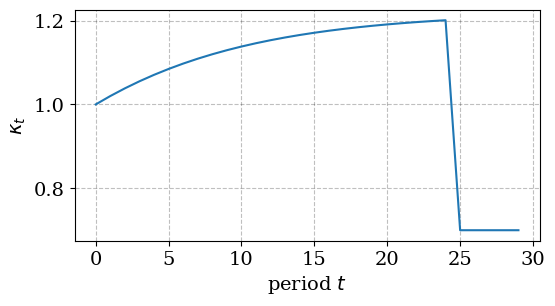

In [16]:
fig, ax = plt.subplots(1,1,figsize=(6,3))

ax.plot(model.par.kappa)

ax.set_xlabel('period $t$')
ax.set_ylabel('$\\kappa_t$')

filepath = f"{folder}/DurablesModel_kappa.svg"
plt.savefig(filepath, bbox_inches='tight')

## 4. <a id='toc4_'></a>[Convergence](#toc0_)

D = 1, algoname = DeepSimulate


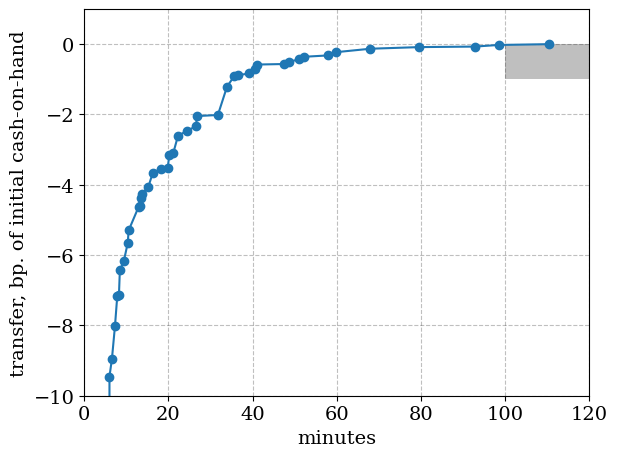

D = 1, algoname = DeepFOC


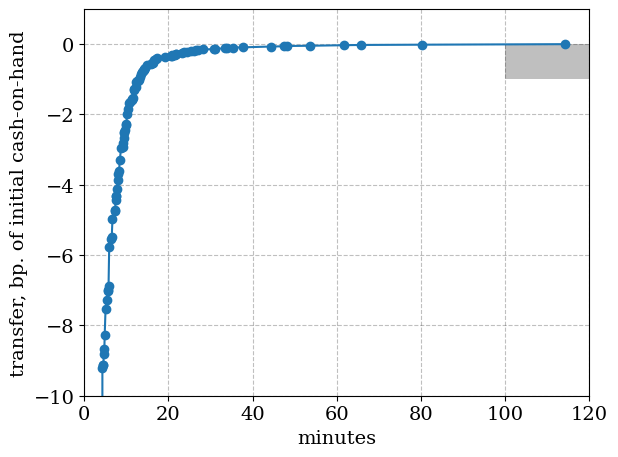

D = 2, algoname = DeepSimulate


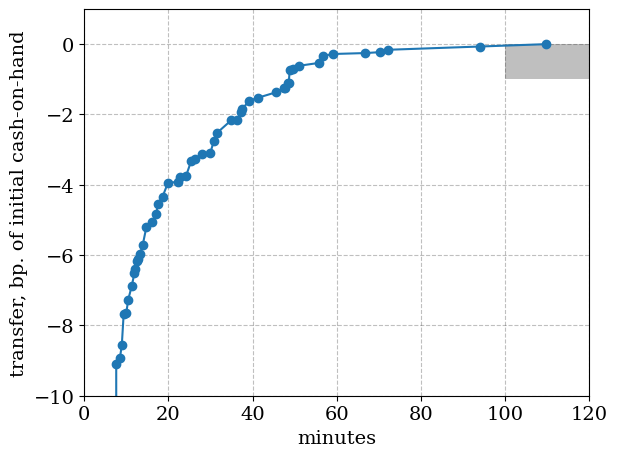

D = 2, algoname = DeepFOC


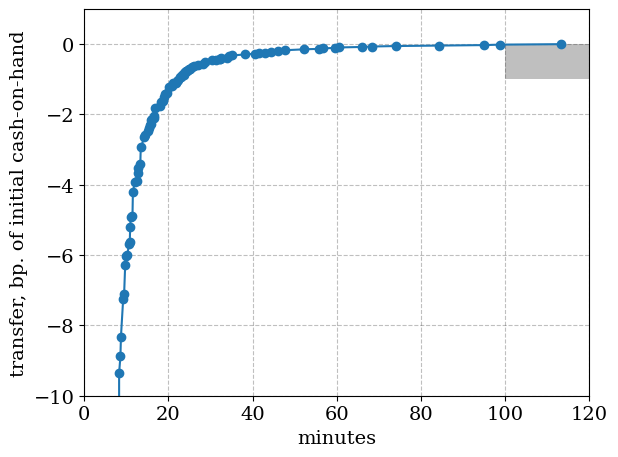

D = 3, algoname = DeepSimulate


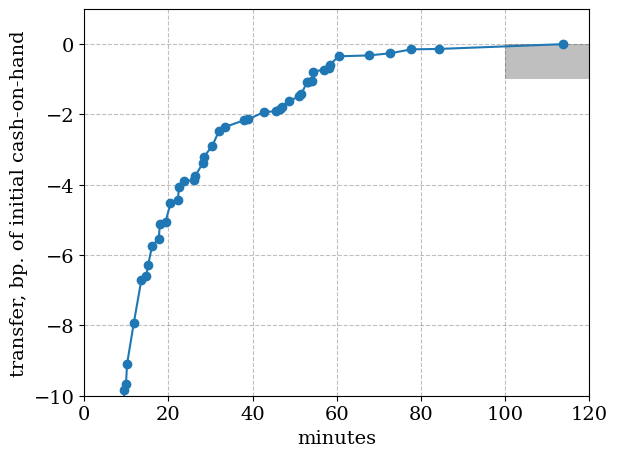

D = 3, algoname = DeepFOC


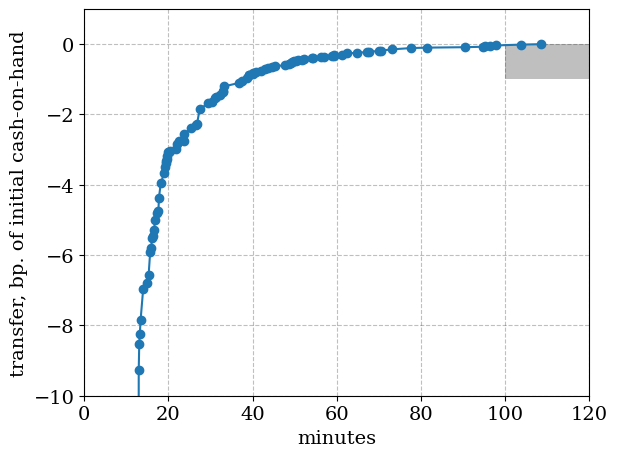

D = 8, algoname = DeepSimulate


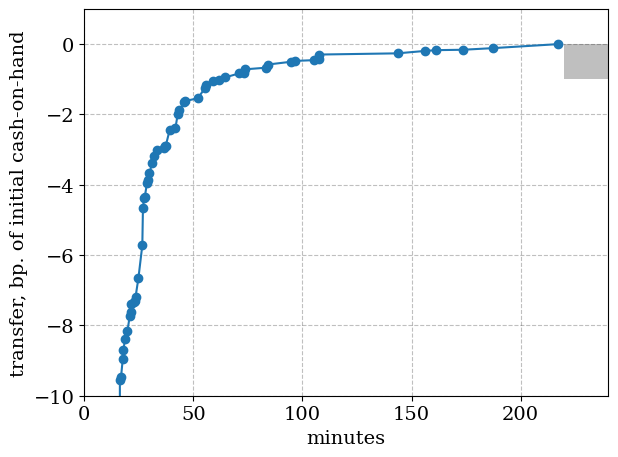

D = 8, algoname = DeepFOC


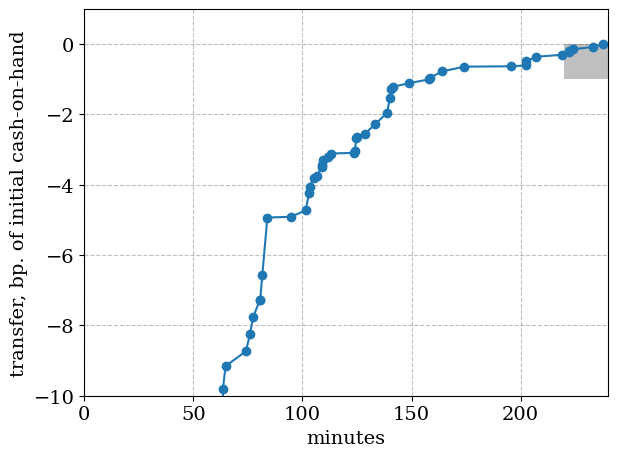

In [17]:
for D in Ds:
    for algoname,extra in [(algoname,None) for algoname in algonames]:
        
        if D == 8 and not extra is None: continue 
        
        print(f'D = {D}, algoname = {algoname}',end='')
        if extra is not None: 
            print(f' {extra}',end='')
        else:
            print('')

        model = models[(algoname,f'{D}D')] if extra is None else models[(algoname,f'{D}D',extra)]
        postfix = f'_DurablesModel_{algoname}_{D}D'
        if extra is not None: postfix += f'_{extra}'

        EconDLSolvers.convergence_plot(model,
                         y_fac=10_000,ylabel='transfer, bp. of initial cash-on-hand',
                         folder=folder,postfix=postfix,close_fig=False)
        
        plt.show()

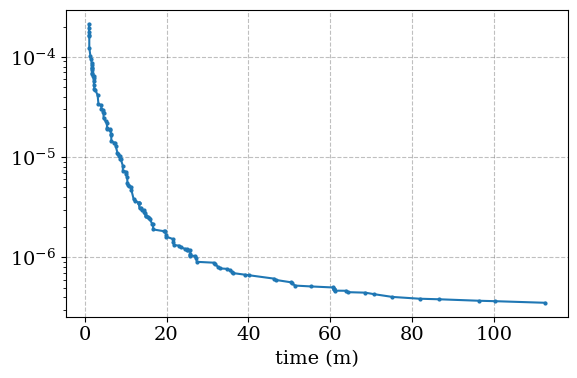

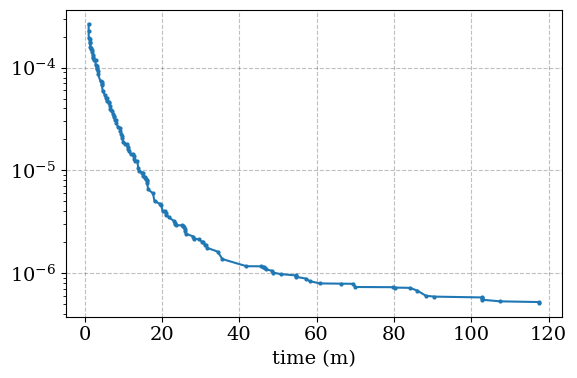

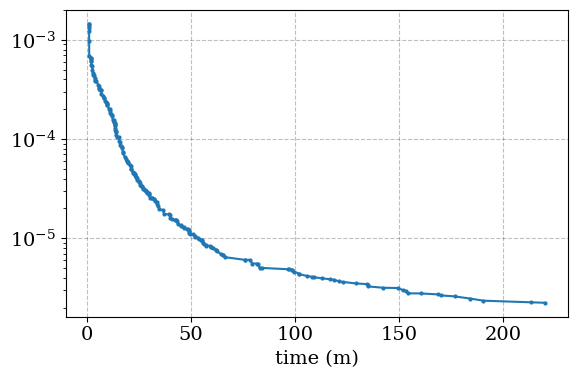

In [18]:
for D in [1,2,8]:
        
    model = models[('DeepFOC',f'{D}D')]
    k_max = model.info['iter']

    x = [model.info[('k_time',k)]/60 for k in range(k_max) if ('policy_loss',k) in model.info and model.info[('k_time',k)]/60 > 1]    
    y = [model.info[('policy_loss',k)] for k in range(k_max) if ('policy_loss',k) in model.info and model.info[('k_time',k)]/60 > 1]

    x_ = []
    y_ = []
    best_yi = np.inf
    for xi,yi in zip(x,y):
        if yi < best_yi:
            x_.append(xi)
            y_.append(yi)
            best_yi = yi

    fig, ax = plt.subplots(1,1,figsize=(6,4))
    # ax.set_title(f'DeepFOC - {D}D')
    ax.plot(x_,y_,'-o',ms='2',color=colors[0])
    ax.set_xlabel('time (m)')
    ax.set_yscale('log')

    fig.tight_layout()
    fig.savefig(f'{folder}/DurablesModel_DeepFOC_{D}D_policy_loss.svg')

    plt.show()


## 5. <a id='toc5_'></a>[Life-cycle profiles](#toc0_)

DP 1


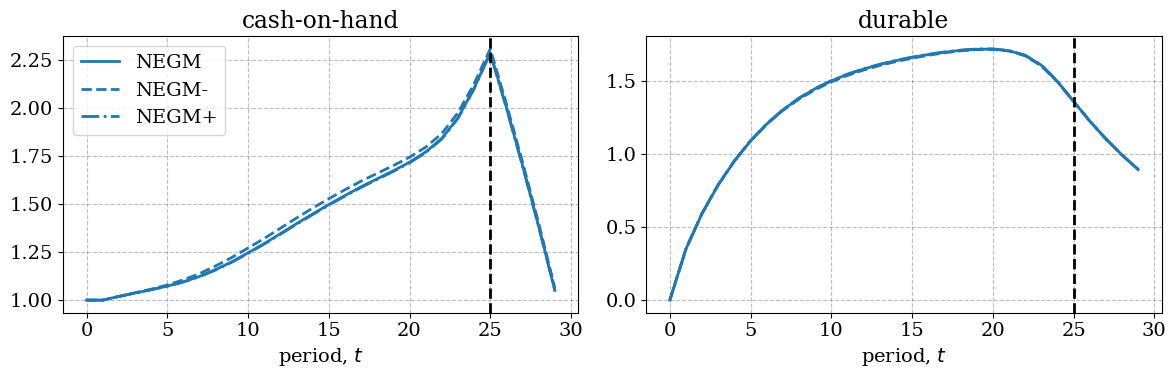

DeepSimulate 1


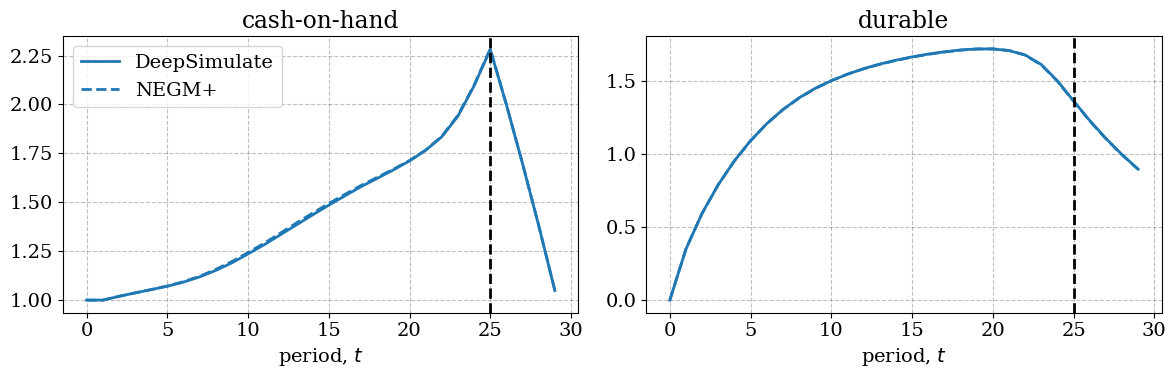

DeepFOC 1


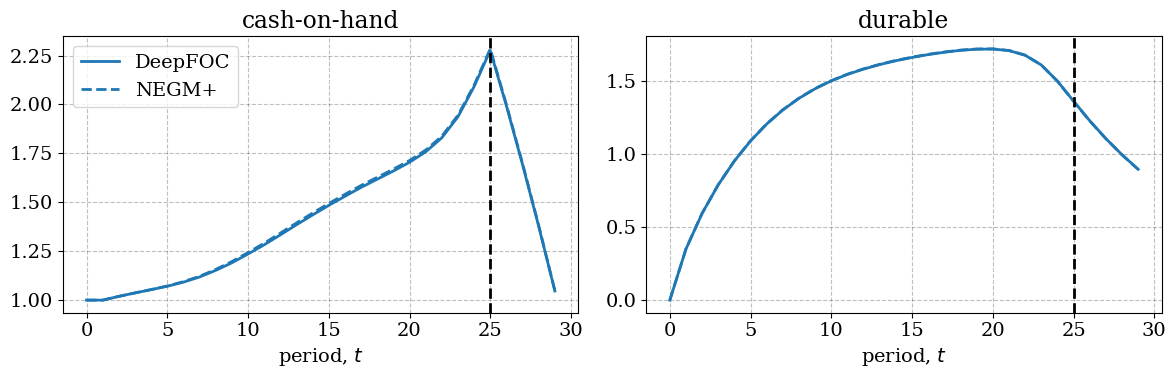

DP 2


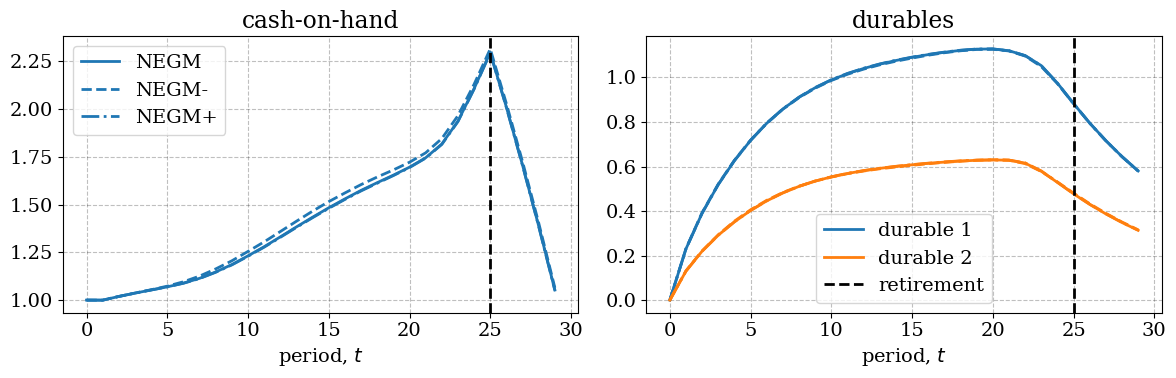

DeepSimulate 2


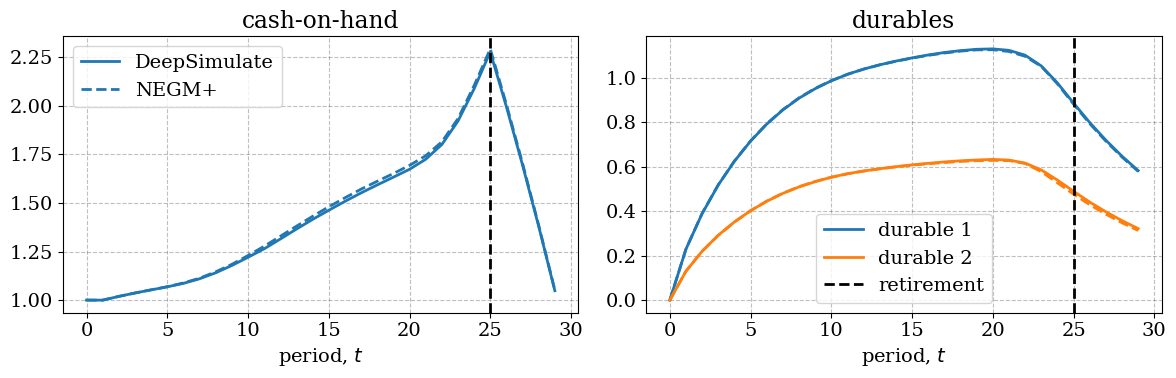

DeepFOC 2


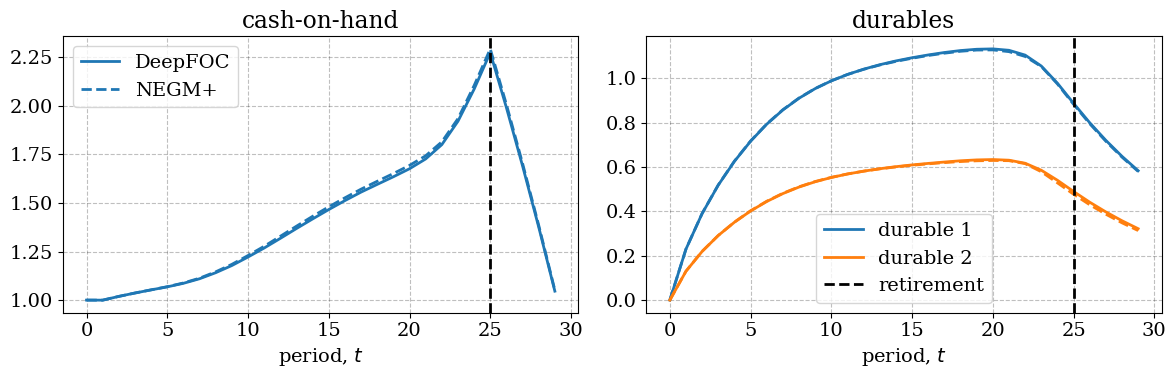

DeepSimulate 3


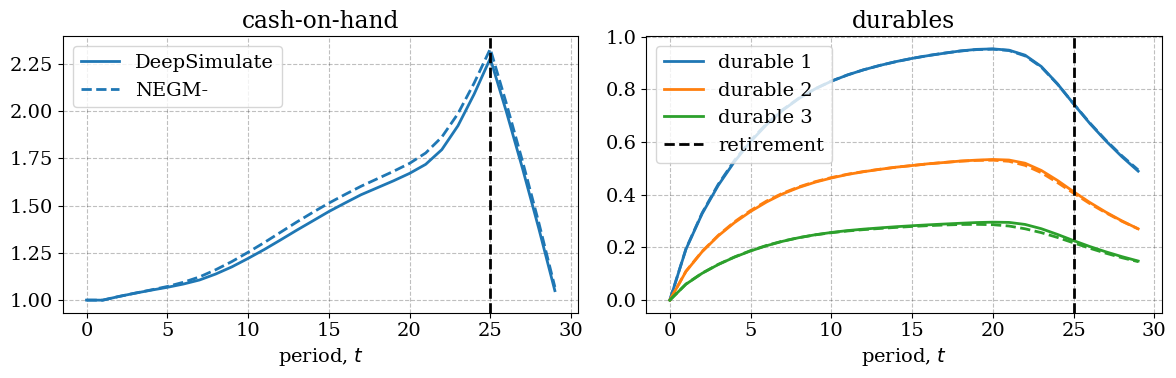

DeepFOC 3


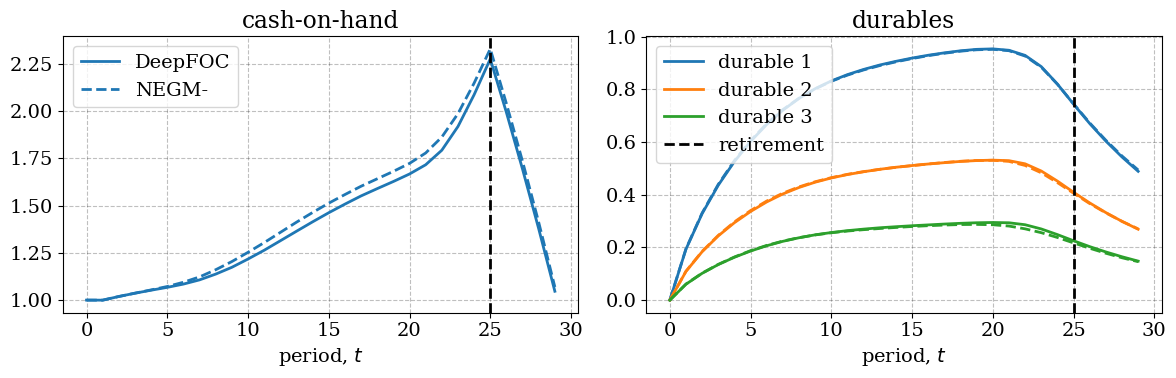

In [19]:
for D in [1,2,3]:
    for algoname in ['DP'] + algonames:

        if algoname == 'DP' and D == 3: continue

        print(algoname,D)

        fig = plt.figure(figsize=(12,4))

        ax = fig.add_subplot(1,2,1)
        if not algoname == 'DP':
            label = algolabels[algoname]
            ax.plot(np.mean(models[(f'{algoname}',f'{D}D')].sim.states[:,:,0],axis=1),label=label,color=colors[0], lw=2)
            if D <= 2:
                ax.plot(np.mean(models[('DP',f'{D}D','fine')].sim.states[:,:,0],axis=1),label='NEGM+',color=colors[0], lw=2,ls='--')
            else:
                ax.plot(np.mean(models[('DP',f'{D}D','rough')].sim.states[:,:,0],axis=1),label='NEGM-',color=colors[0], lw=2,ls='--')
        else:
            ax.plot(np.mean(models[('DP',f'{D}D')].sim.states[:,:,0],axis=1),label='NEGM',color=colors[0], lw=2,ls='-')
            ax.plot(np.mean(models[('DP',f'{D}D','rough')].sim.states[:,:,0],axis=1),label='NEGM-',color=colors[0], lw=2,ls='--')
            ax.plot(np.mean(models[('DP',f'{D}D','fine')].sim.states[:,:,0],axis=1),label='NEGM+',color=colors[0], lw=2,ls='-.')
        
        ax.axvline(x=model.par.T_retired, lw=2,color='black', linestyle='--')
        ax.set_xlabel('period, $t$')
        ax.set_title('cash-on-hand')
        ax.legend()

        ax = fig.add_subplot(1,2,2)
        if not algoname == 'DP':
            for k in range(D):
                ax.plot(np.mean(models[(f'{algoname}',f'{D}D')].sim.states[:,:,2+k],axis=1),label=f'durable {1+k}',color=colors[k], lw=2)
                if D <= 2:
                    ax.plot(np.mean(models[('DP',f'{D}D')].sim.states[:,:,2+k],axis=1),color=colors[k], lw=2,ls='--')
                else:               
                    ax.plot(np.mean(models[('DP',f'{D}D','rough')].sim.states[:,:,2+k],axis=1),color=colors[k], lw=2,ls='--')
        else:
            for k in range(D):
                ax.plot(np.mean(models[('DP',f'{D}D')].sim.states[:,:,2+k],axis=1),label=f'durable {1+k}',color=colors[k], lw=2,ls='-')
                ax.plot(np.mean(models[('DP',f'{D}D','rough')].sim.states[:,:,2+k],axis=1),color=colors[k], lw=2,ls='--')
                ax.plot(np.mean(models[('DP',f'{D}D','fine')].sim.states[:,:,2+k],axis=1),color=colors[k], lw=2,ls='-.')
                
        ax.axvline(x=model.par.T_retired,lw=2, label='retirement',color='black', linestyle='--')
        ax.set_xlabel('period, $t$')
        
        if D == 1:
            ax.set_title('durable')
        else:
            ax.set_title('durables')
            ax.legend()

        fig.tight_layout()
        fig.savefig(f'{folder}/DurablesModel_lcp_{D}D_{algoname}.svg')

        plt.show()

DeepFOC, 1D [basename: DeepSimulate]


DeepFOC, 2D [basename: DeepSimulate]


DeepFOC, 3D [basename: DeepSimulate]


DeepFOC, 8D [basename: DeepSimulate]


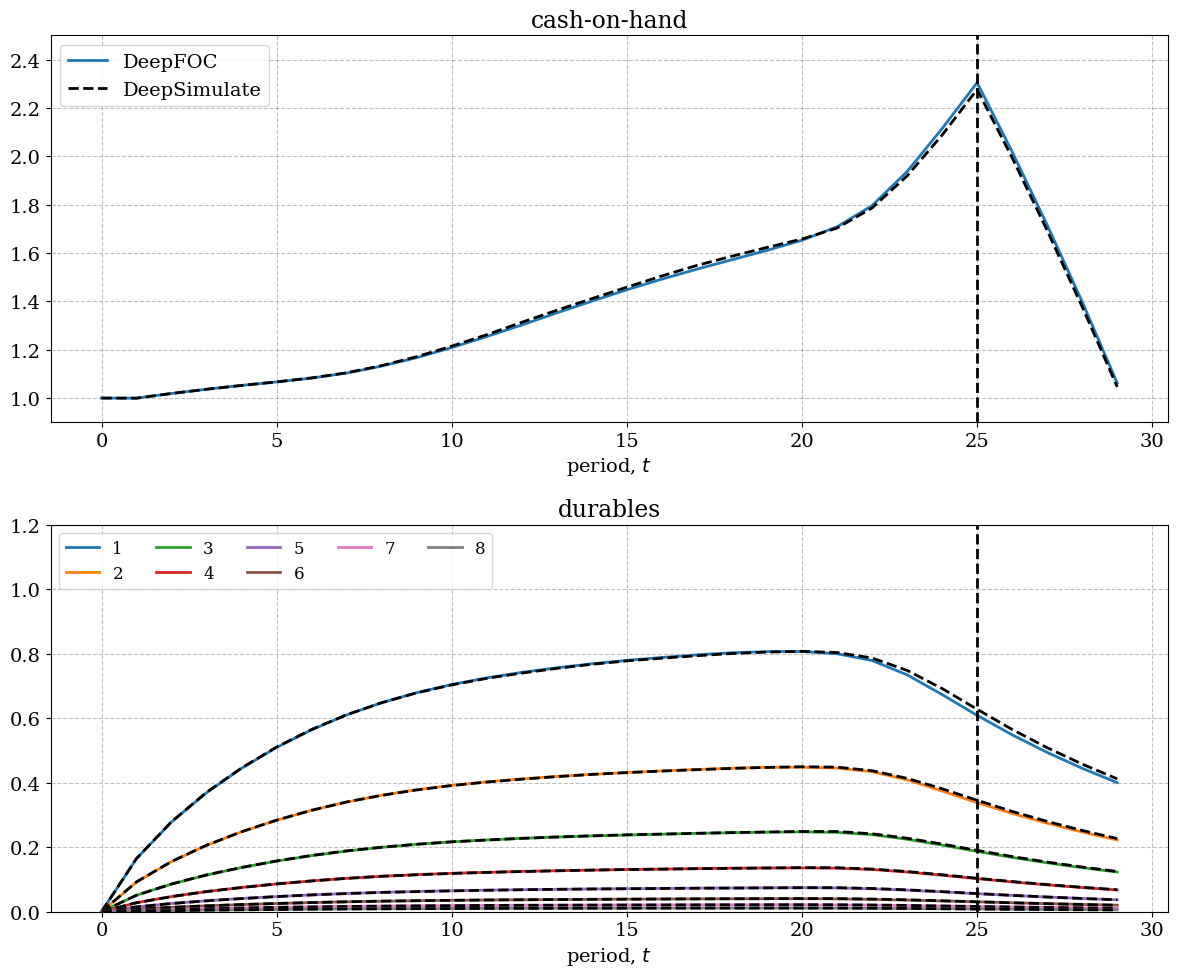

In [20]:
basenames = ['DeepSimulate']

for basename in basenames:
    for D in [1,2,3,8]:
        for algoname in algonames: 

            if algoname == basename: continue

            label = algolabels[algoname]
            print(f'{algoname}, {D}D [basename: {basename}]')

            fig = plt.figure(figsize=(12,10))

            ax = fig.add_subplot(2,1,1)
            ax.plot(np.mean(models[(f'{algoname}',f'{D}D')].sim.states[:,:,0],axis=1),label=label,color=colors[0],linewidth=2)
            ax.plot(np.mean(models[(f'{basename}',f'{D}D')].sim.states[:,:,0],axis=1),label=basename,color='black',linewidth=2,ls='--')
            ax.axvline(x=model.par.T_retired, linewidth=2,color='black',linestyle='--')
            
            ax.set_ylim([0.9,2.5])
            ax.set_xlabel('period, $t$')
            ax.set_title('cash-on-hand')
            ax.legend()

            ax = fig.add_subplot(2,1,2)
            for k in range(D):
                delta = models[(f'{algoname}',f'{D}D')].par.delta[k]
                ax.plot(np.mean(models[(f'{algoname}',f'{D}D')].sim.states[:,:,2+k],axis=1),color=colors[k],label=f'{1+k}',linewidth=2)
                ax.plot(np.mean(models[(f'{basename}',f'{D}D')].sim.states[:,:,2+k],axis=1),color='black', linewidth=2,ls='--')
            
            ax.axvline(x=model.par.T_retired,linewidth=2,color='black', linestyle='--')
            if D < 3:
                ax.set_ylim([0,1.0])
            elif D == 3:
                ax.set_ylim([0,0.7])
            elif D == 8:
                ax.set_ylim([0,1.2])
            ax.set_xlabel('period, $t$')
            ax.set_title('durables')
            ax.legend(ncols=5,fontsize=12)

            fig.tight_layout()

            filepath = f"{folder}/DurablesModel_lcp_{D}D_{algoname}_base{basename}.svg"
            fig.savefig(filepath)

            if D <= 3:
                plt.close(fig)
                display(HTML(f'<a href="{filepath}">{filepath}</a>'))
            else:
                plt.show()

### 5.1. <a id='toc5_1_'></a>[Cross-section](#toc0_)

In [21]:
def plot_cross_section(varname,algoname,D,models,basename,baselabel,N=10_000,ts=None,label=None,do_display=True):
    
    label_algo = algoname if label is None else label
    ts = [5,15,25] if ts is None else ts

    fig = plt.figure(figsize=(18,6))        
    for i_t,t in enumerate(ts):

        ax = fig.add_subplot(1,len(ts),1+i_t)

        m_base = get_model(models,basename,D).sim.__dict__[varname][t,:N]
        m_algo = get_model(models,algoname,D).sim.__dict__[varname][t,:N]
        x_max = max(np.max(m_base),np.max(m_algo)) * 1.05

        # 45 degree
        ax.plot([0,x_max],[0,x_max],color='black',ls='-',lw=3,alpha=0.5,label='45 degree line')
        ax.set_title(f't={t}')

        # poly fit
        a,b,c,d = np.polyfit(m_base,m_algo,3)
        x_fit = np.linspace(0,x_max,1000)
        y_fit = a*x_fit**3 + b*x_fit**2 + c*x_fit + d
        ax.plot(x_fit,y_fit,color=colors[0],ls='-',lw=2,label='best cubic fit')

        # scatter
        ax.scatter(m_base,m_algo,color='black',s=5,label='agents',rasterized=True)
        
        # box            
        m_corr = np.corrcoef(m_base,m_algo)[0,1]
        m_abs_diff_rel = np.mean(np.abs((m_algo-m_base)/m_base))
        box_text = ''
        box_text += f'corr.: {m_corr:.3f}\n'
        box_text += f'mean abs. rel. diff: {m_abs_diff_rel:.3f}'
        ax.text(0.95*x_max,0.10*x_max,box_text,fontsize=10,bbox=dict(facecolor='white',alpha=0.75),ha='right')

        # details
        ax.set_xlim(0,x_max)
        ax.set_xlabel(f'{varname}, {baselabel}')
        ax.set_ylim(0,x_max)
        ax.set_ylabel(f'{varname}, {label_algo}')

        from matplotlib.ticker import MaxNLocator
        loc = MaxNLocator(nbins=6)
        ax.xaxis.set_major_locator(loc)
        ax.yaxis.set_major_locator(loc)

        if i_t == 0: ax.legend(loc='upper left')

    fig.tight_layout()
    filepath = f'{folder}/DurablesModel_cross_section_{varname}_{D}D_{algoname}_{basename}.svg'
    fig.savefig(filepath)

    if do_display: 
        plt.show()
    else:
        plt.close(fig)
        display(HTML(f'<a href="{filepath}">{filepath}</a>'))

DeepSimulate, D = 1 [basename = 'DP'] m


DeepSimulate, D = 1 [basename = 'DP'] d0


DeepSimulate, D = 2 [basename = 'DP'] m


DeepSimulate, D = 2 [basename = 'DP'] d0


DeepSimulate, D = 2 [basename = 'DP'] d1


DeepSimulate, D = 3 [basename = 'DP_rough'] m


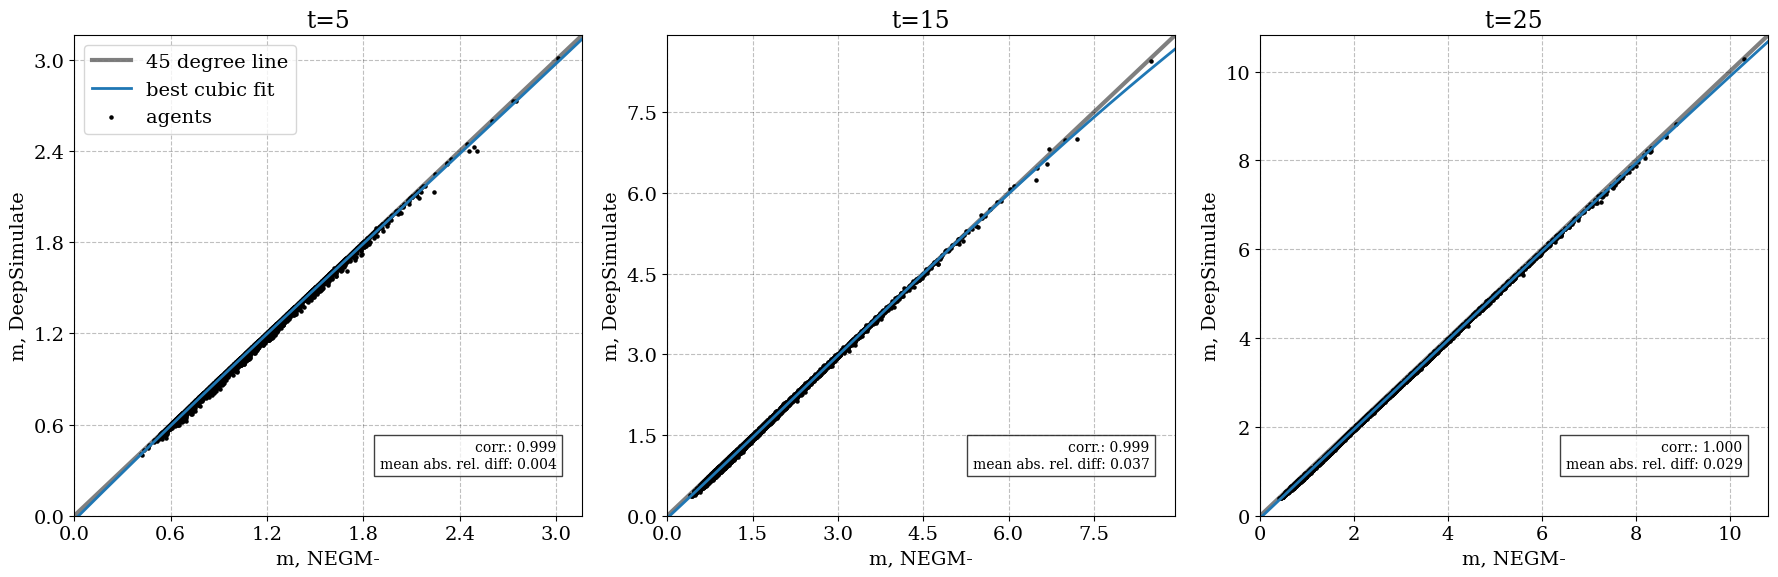

DeepSimulate, D = 3 [basename = 'DP_rough'] d0


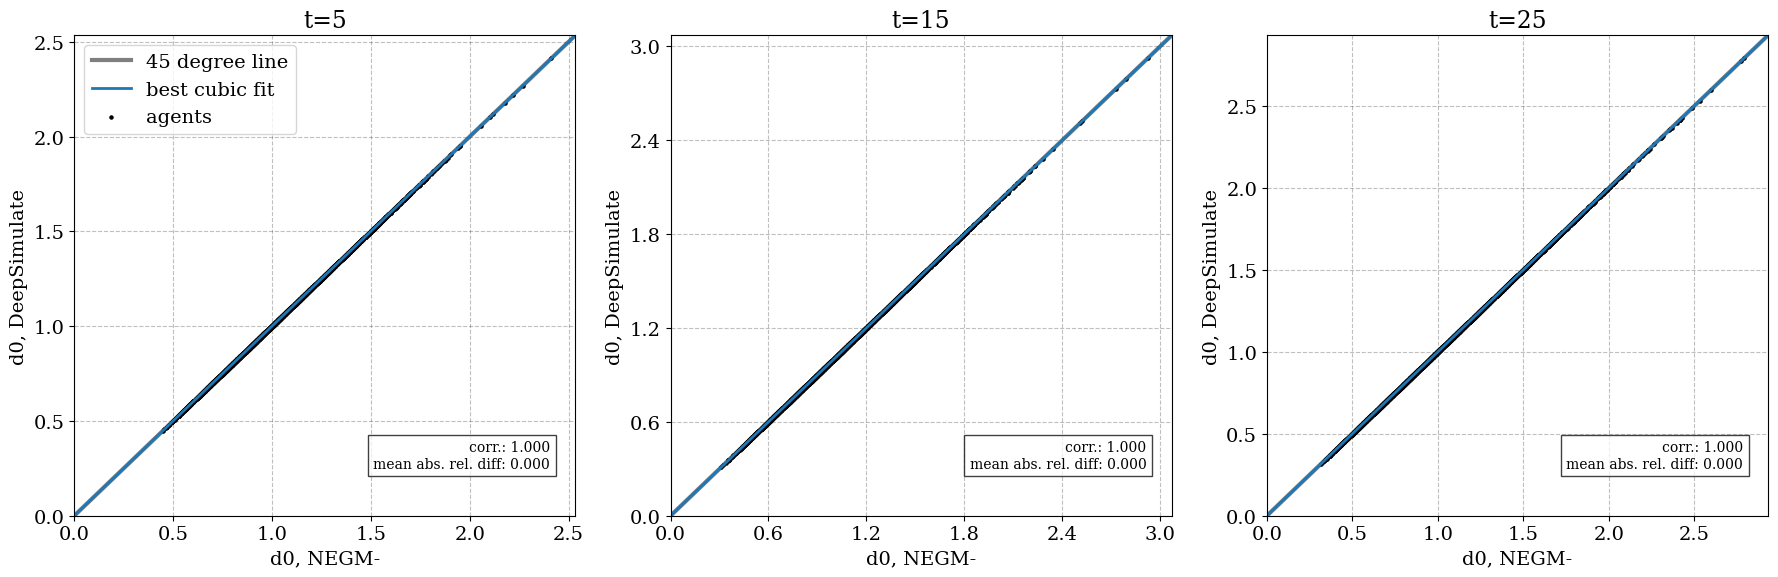

DeepSimulate, D = 3 [basename = 'DP_rough'] d1


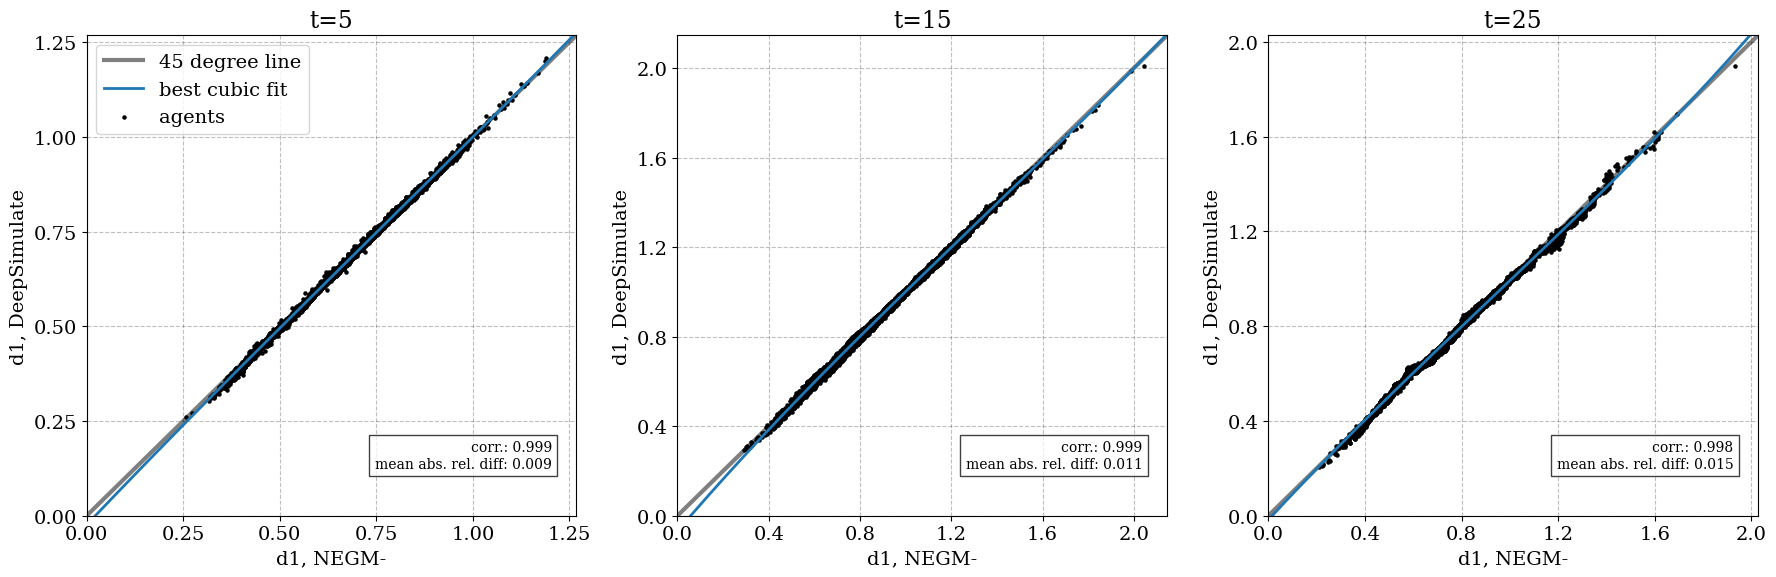

DeepSimulate, D = 3 [basename = 'DP_rough'] d2


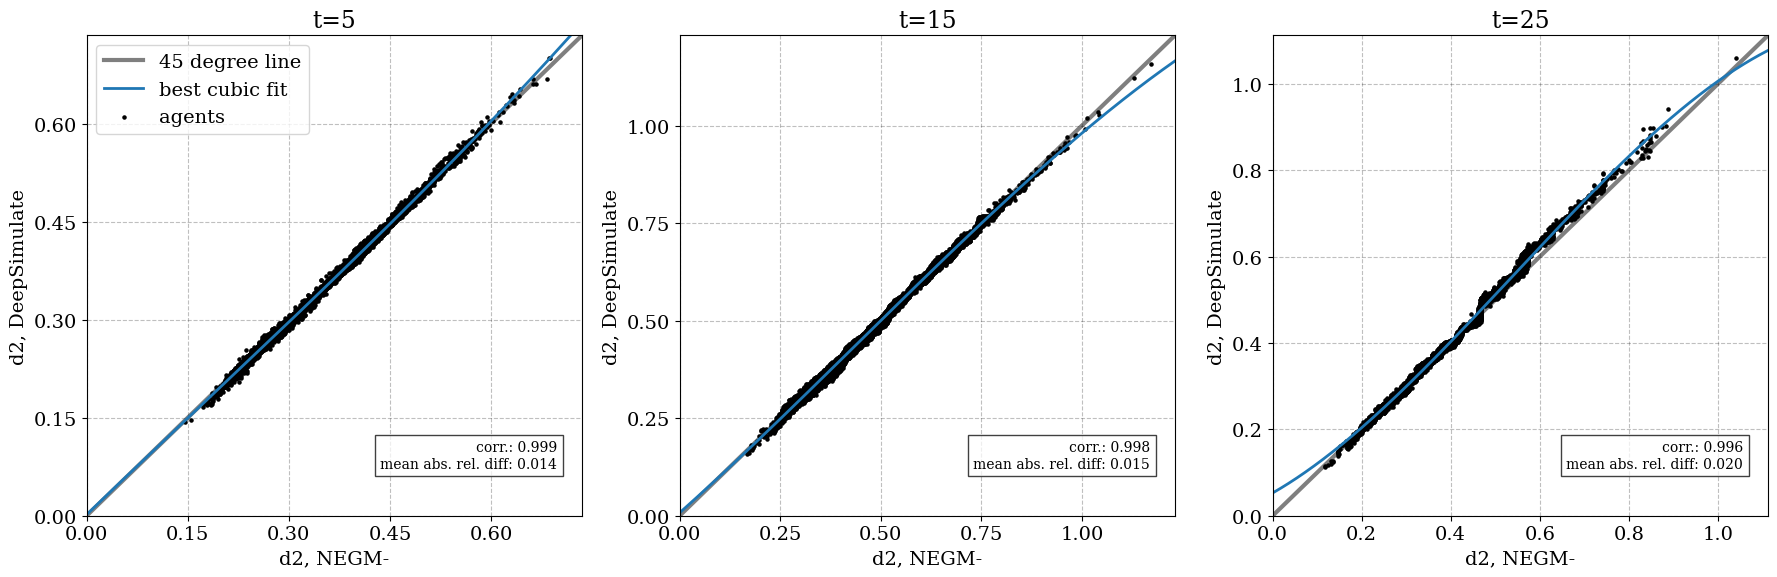

DeepFOC, D = 1 [basename = 'DP'] m


DeepFOC, D = 1 [basename = 'DP'] d0


DeepFOC, D = 2 [basename = 'DP'] m


DeepFOC, D = 2 [basename = 'DP'] d0


DeepFOC, D = 2 [basename = 'DP'] d1


DeepFOC, D = 3 [basename = 'DP_rough'] m


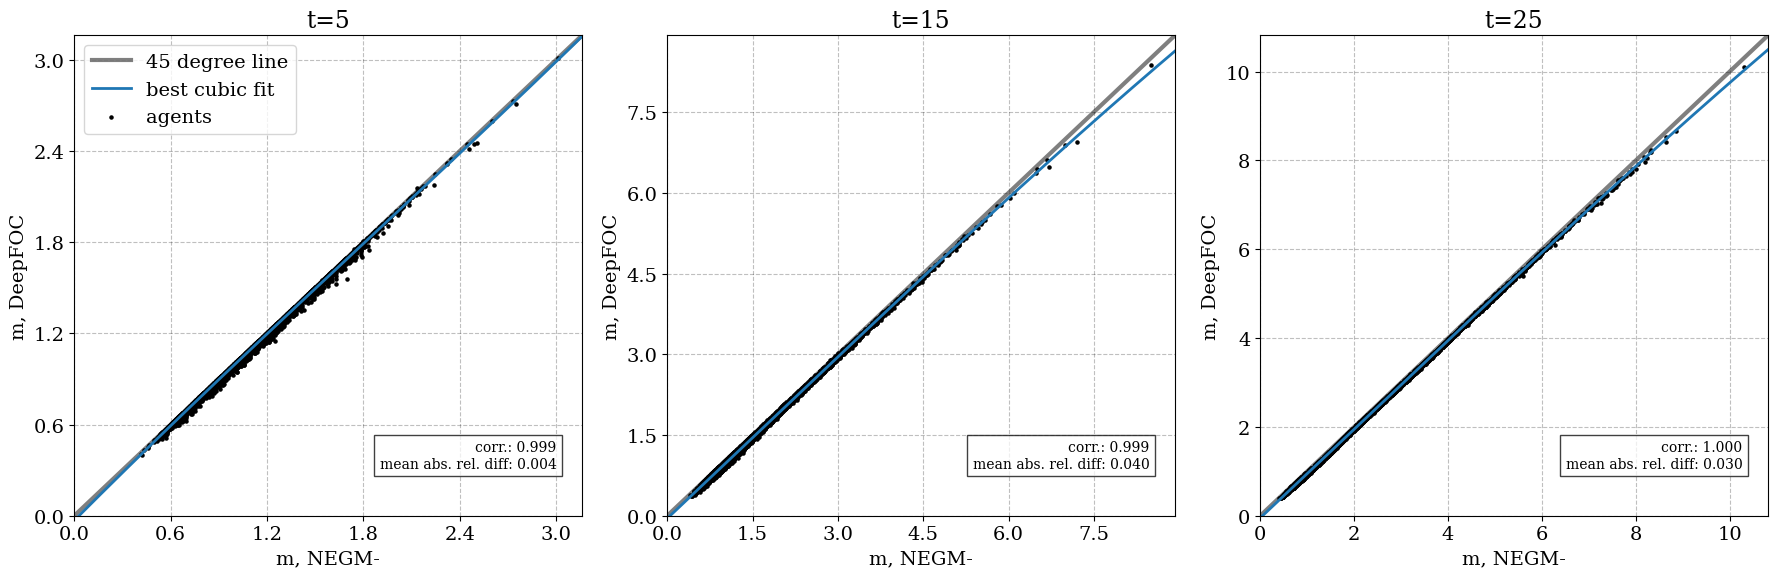

DeepFOC, D = 3 [basename = 'DP_rough'] d0


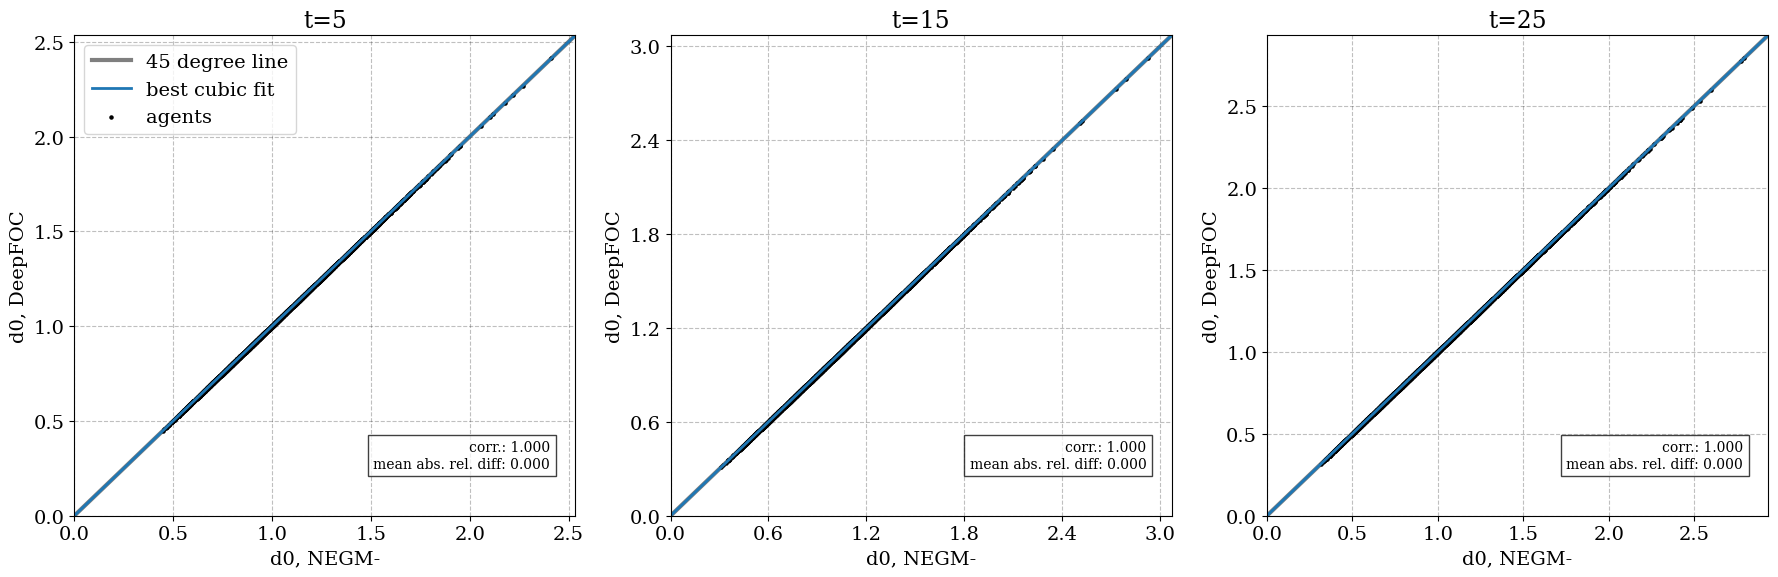

DeepFOC, D = 3 [basename = 'DP_rough'] d1


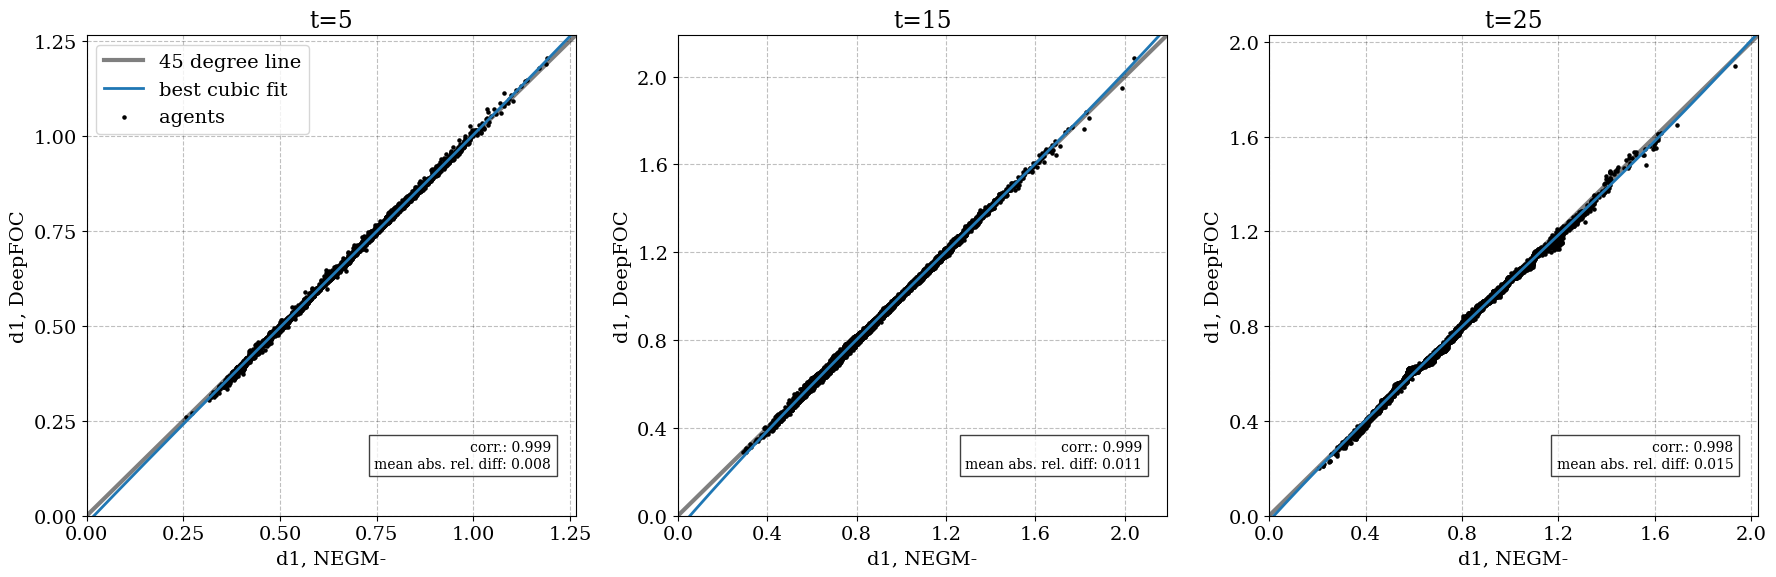

DeepFOC, D = 3 [basename = 'DP_rough'] d2


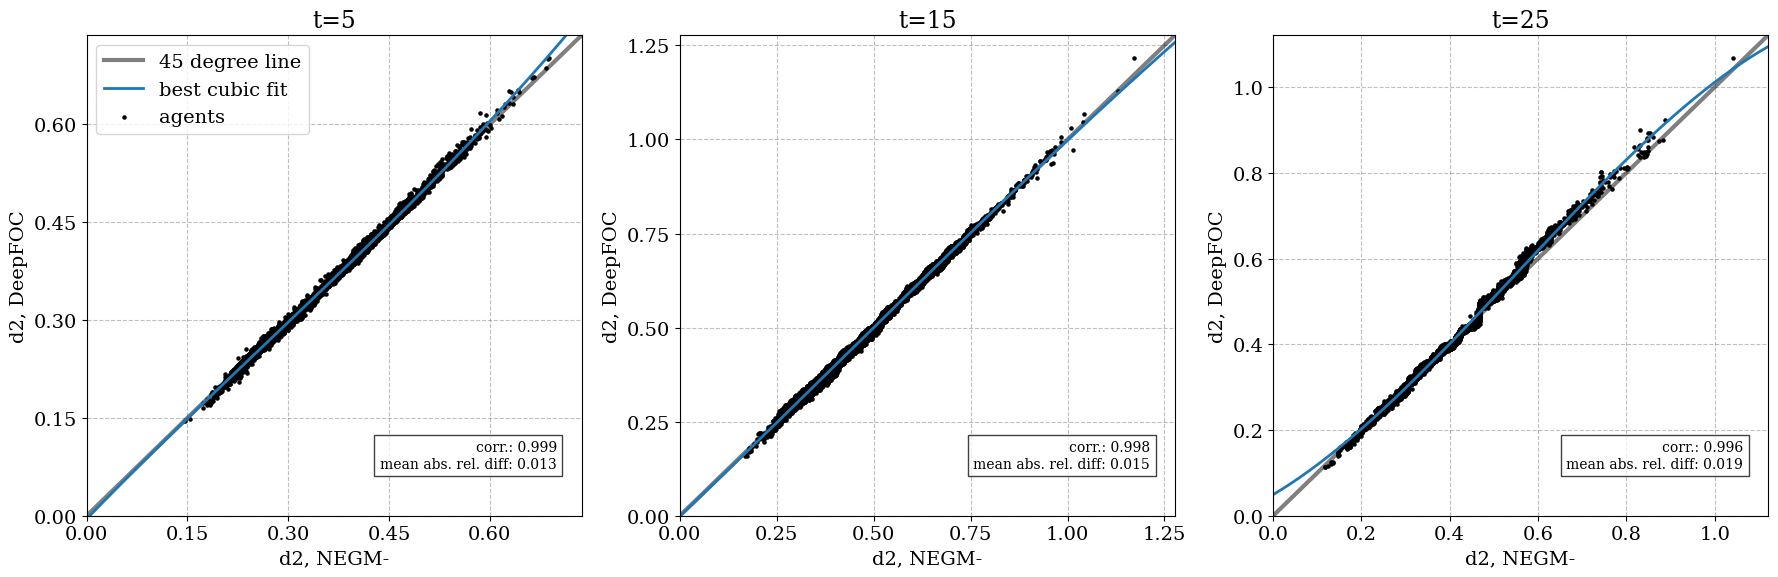

DeepFOC, D = 8 [basename = 'DeepSimulate'] m


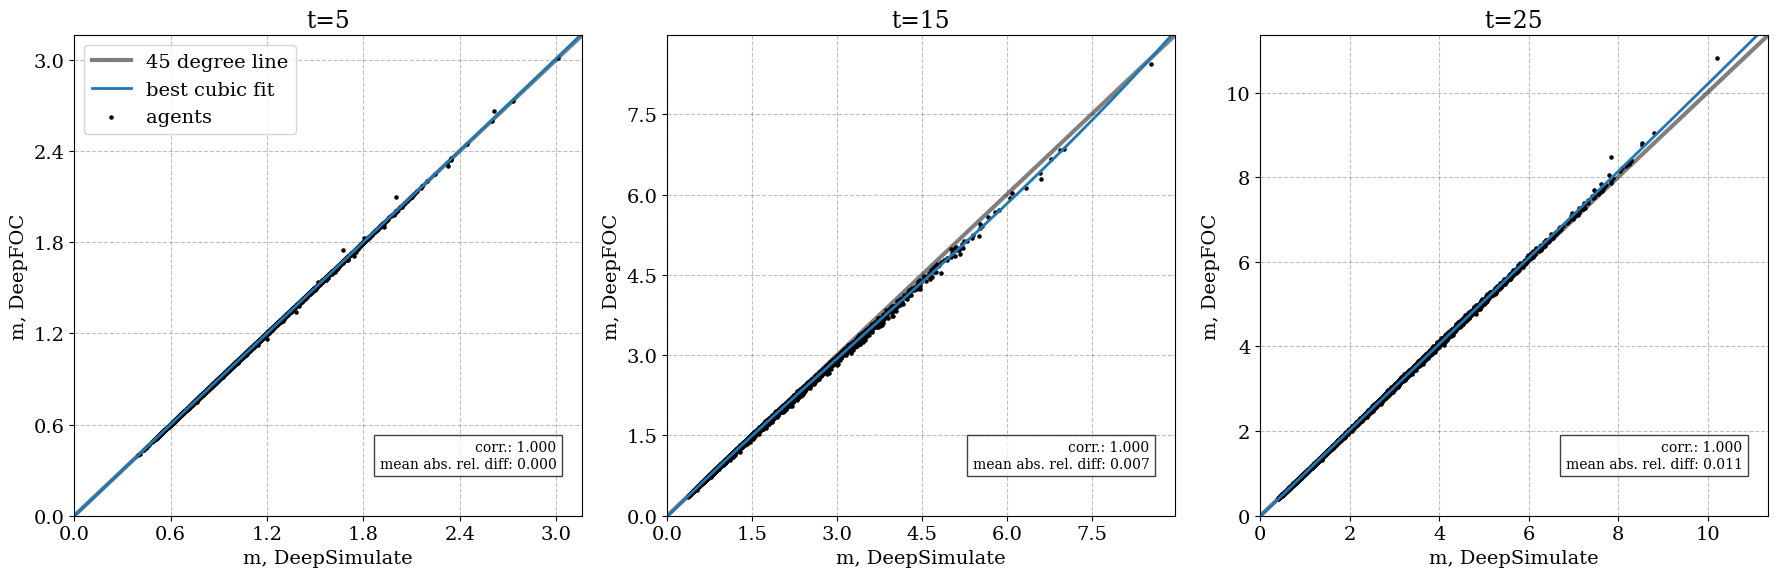

DeepFOC, D = 8 [basename = 'DeepSimulate'] d0


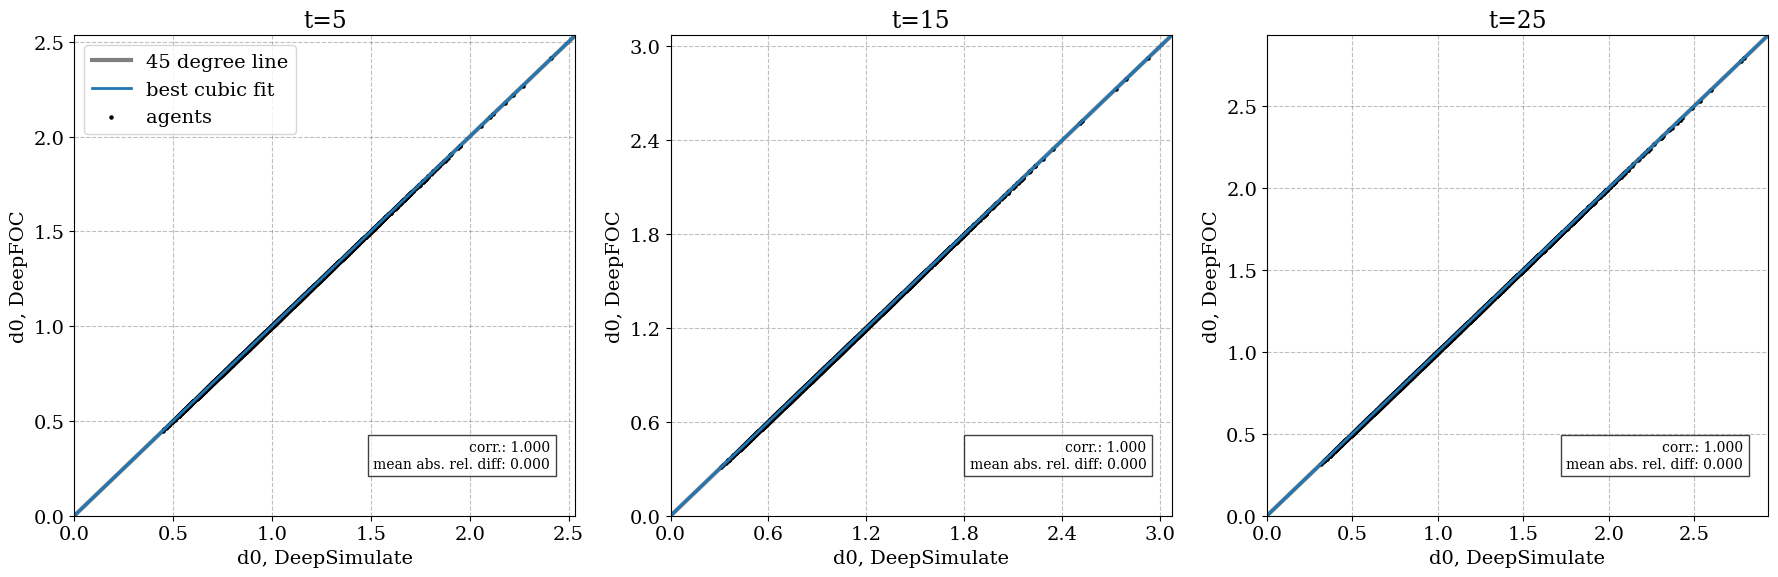

DeepFOC, D = 8 [basename = 'DeepSimulate'] d1


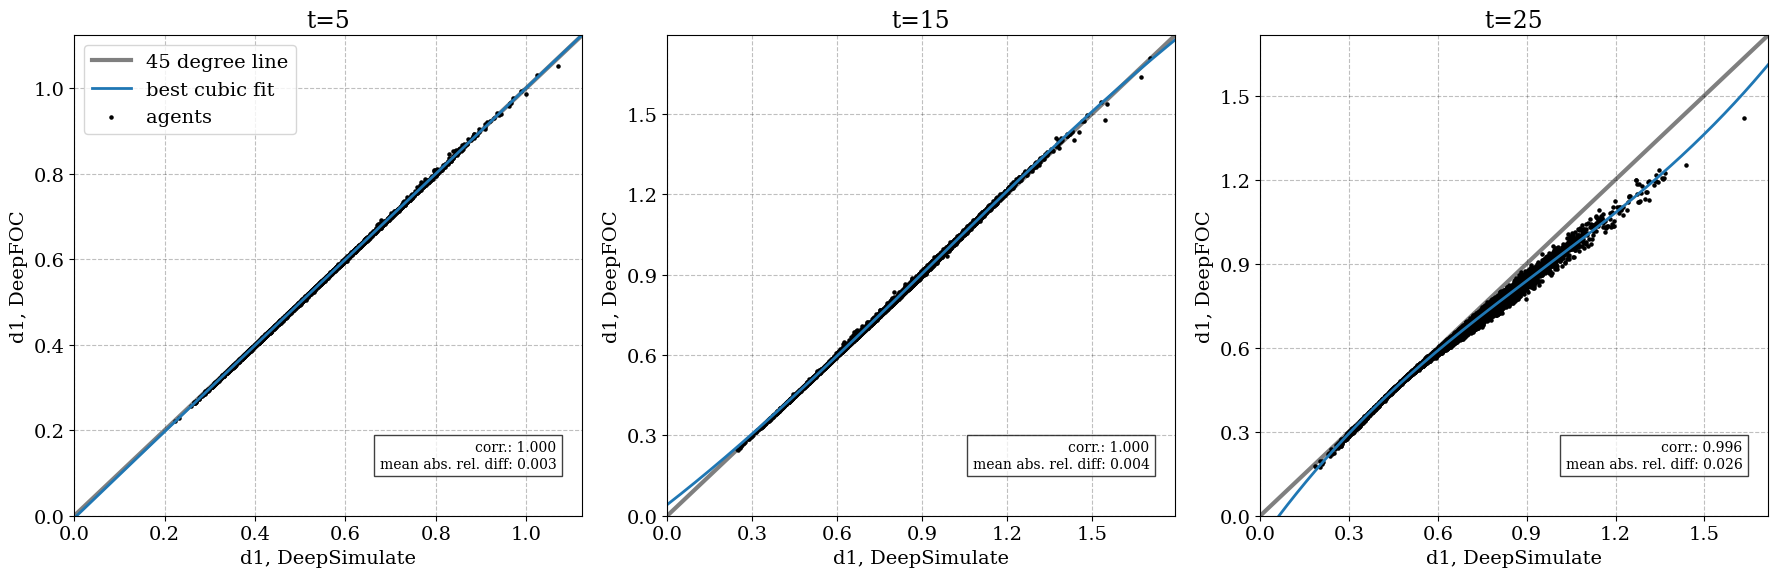

DeepFOC, D = 8 [basename = 'DeepSimulate'] d2


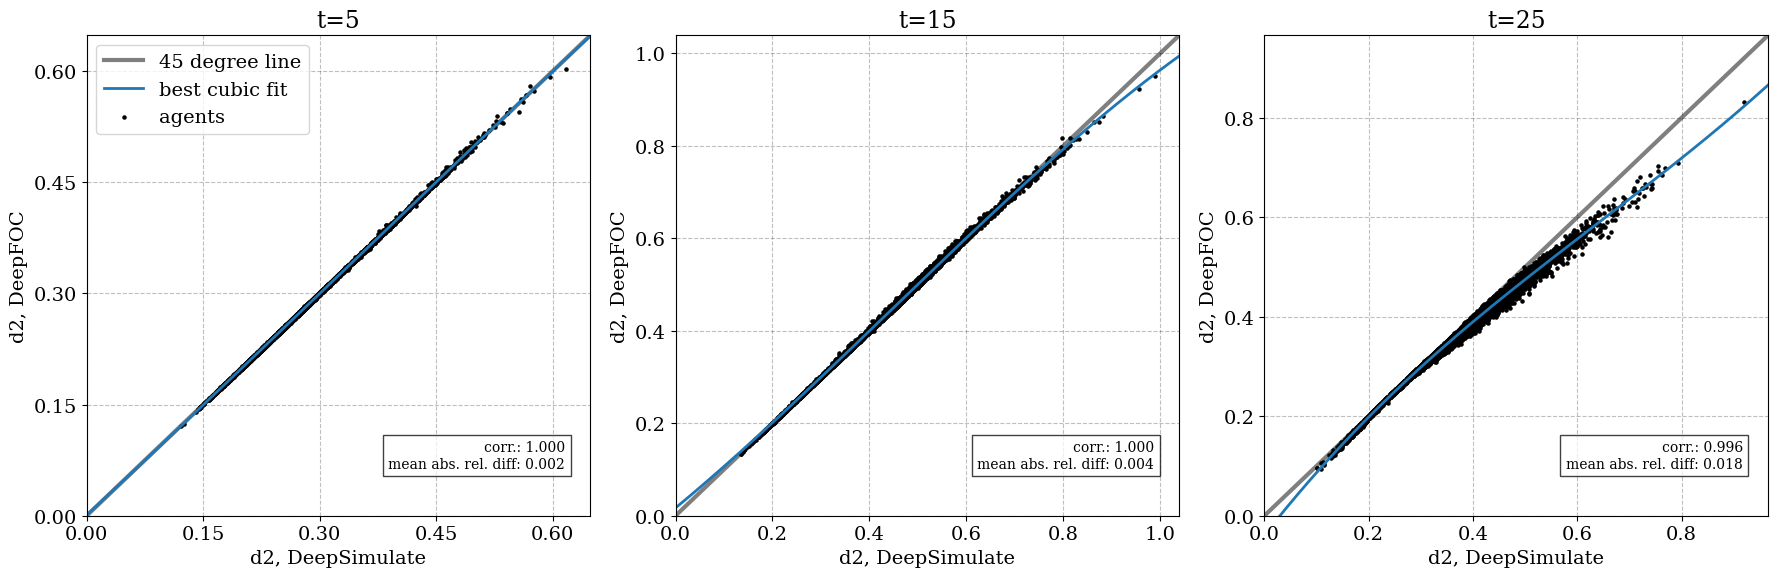

DeepFOC, D = 8 [basename = 'DeepSimulate'] d3


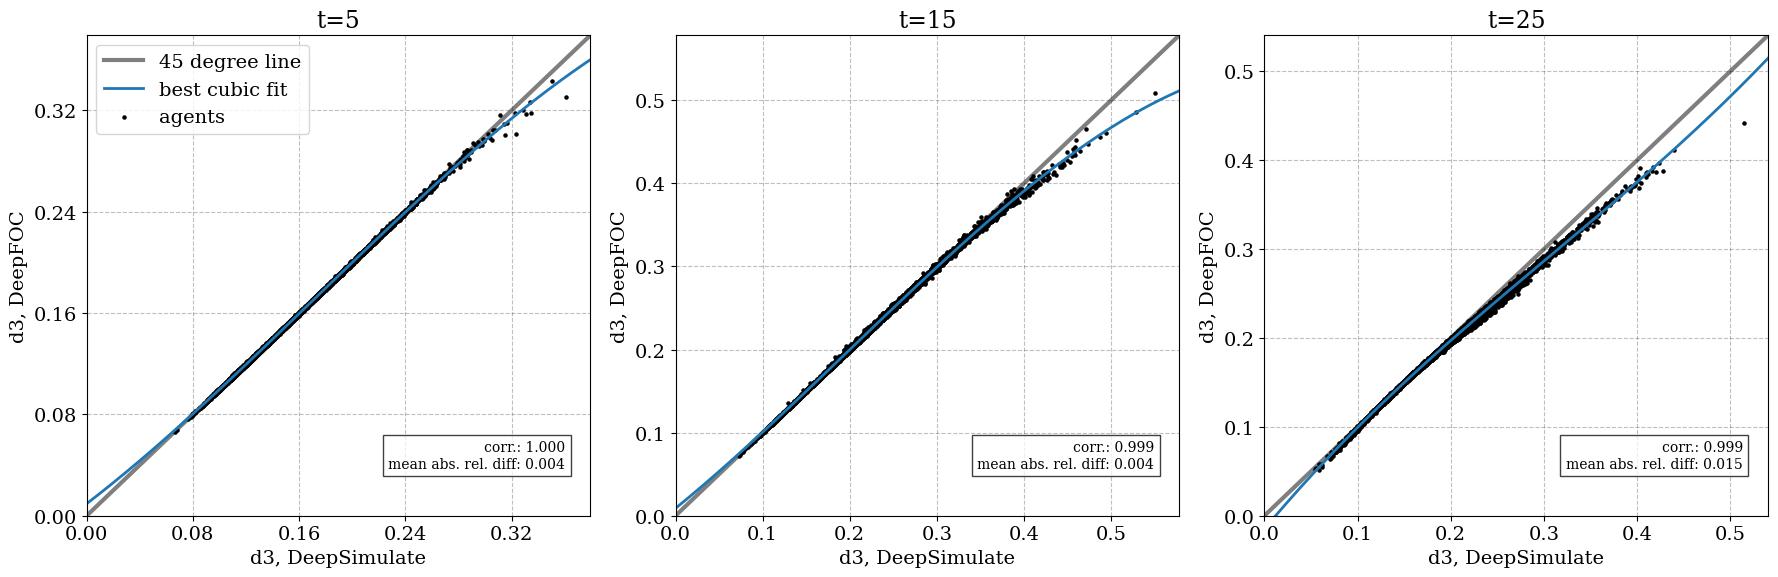

DeepFOC, D = 8 [basename = 'DeepSimulate'] d4


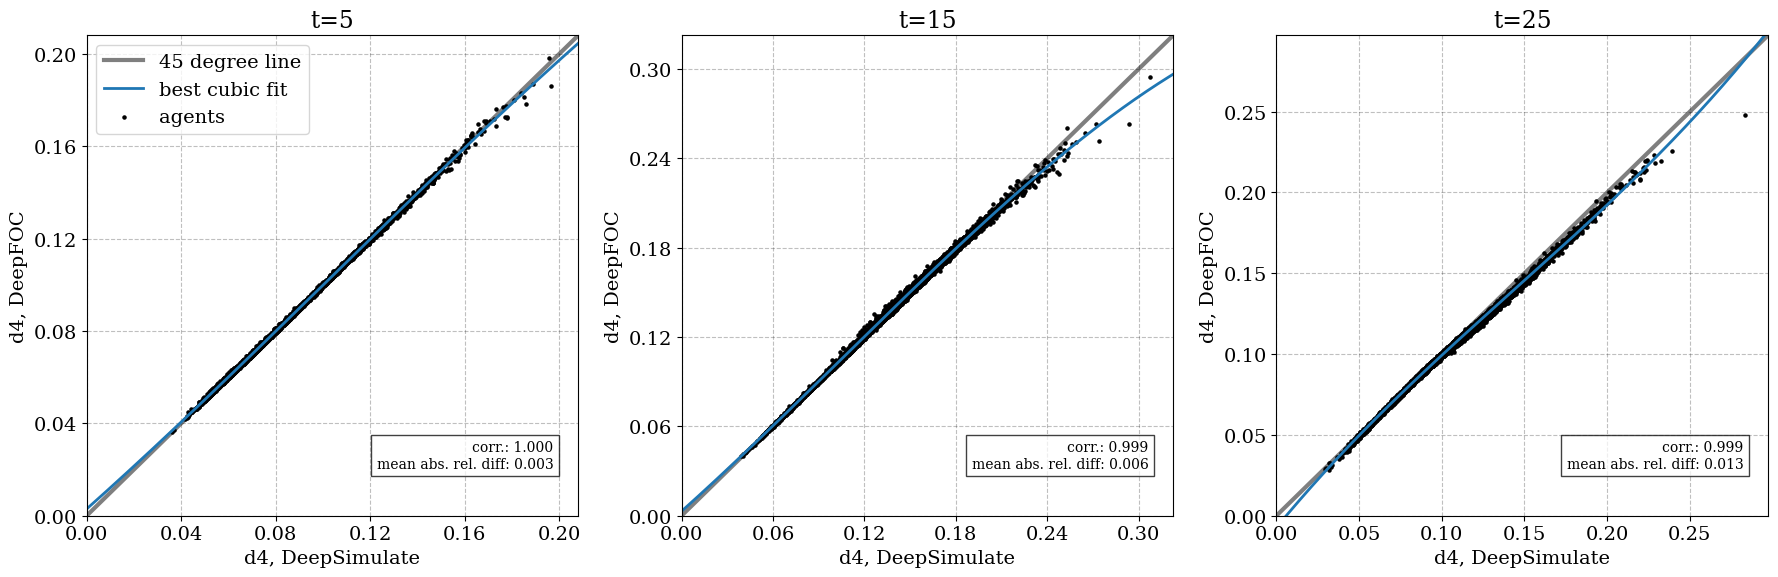

DeepFOC, D = 8 [basename = 'DeepSimulate'] d5


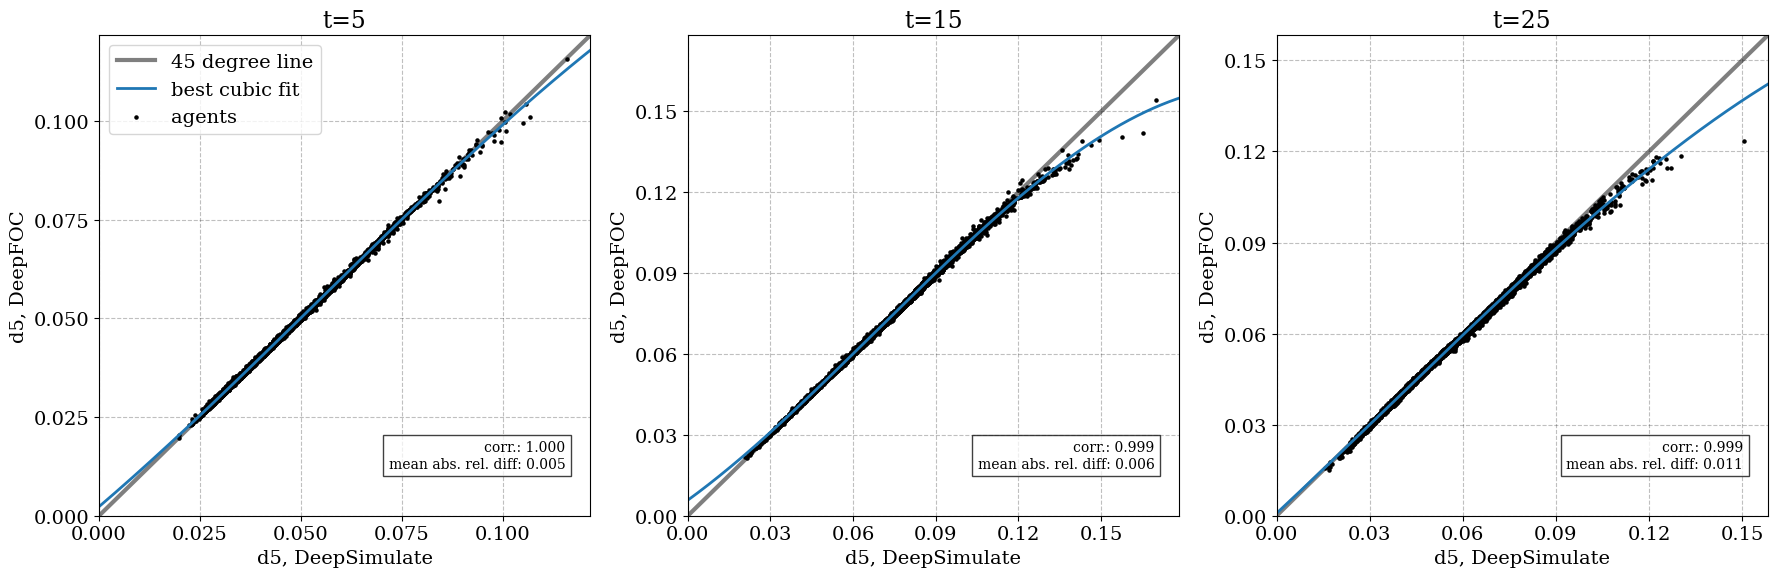

DeepFOC, D = 8 [basename = 'DeepSimulate'] d6


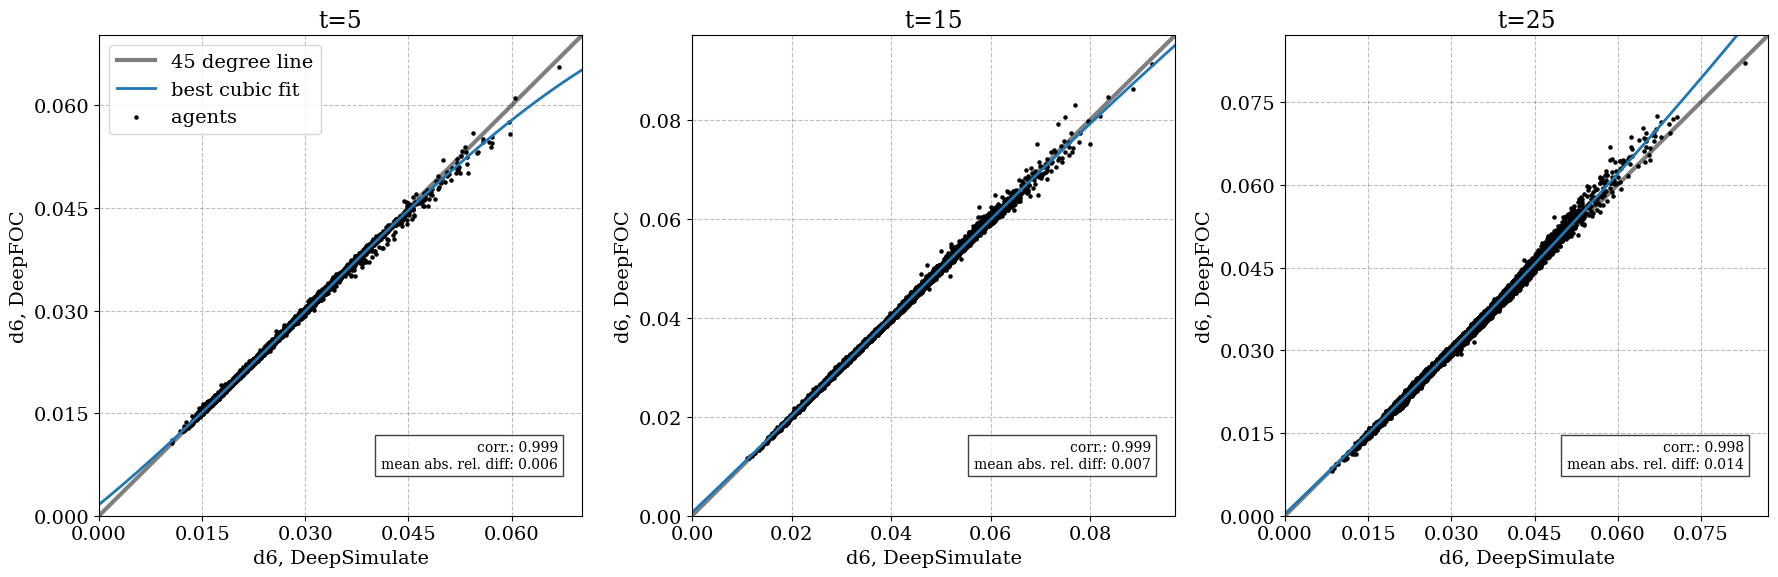

DeepFOC, D = 8 [basename = 'DeepSimulate'] d7


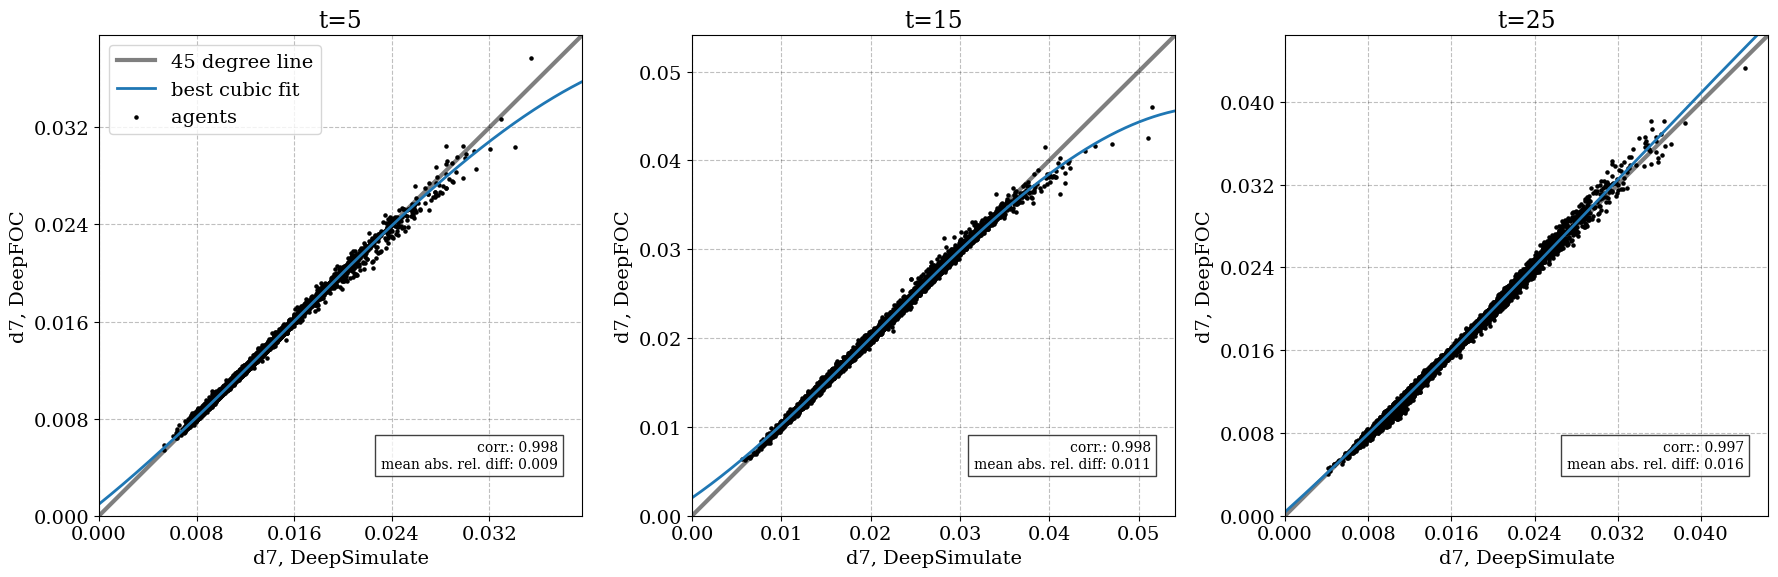

In [22]:
Ds_ = [1,2,3,8]
for i_algo,algoname in enumerate(algonames):        
    for D in Ds_:

        if D in [1,2]:
            basename = 'DP'
            baselabel = 'NEGM+'
            do_display = False
        elif D == 3:
            basename = 'DP_rough'
            baselabel = 'NEGM-'
            do_display = True
        elif D == 8:
            basename = 'DeepSimulate'
            baselabel = 'DeepSimulate'
            do_display = True

        if algoname == basename: continue

        for varname in ['m'] + [f'd{k}' for k in range(D)]:
            print(f'{algoname}, {D = } [{basename = }] {varname}')
            plot_cross_section(varname,algoname,D,models,basename,baselabel,do_display=do_display)        

## 6. <a id='toc6_'></a>[Transfer](#toc0_)

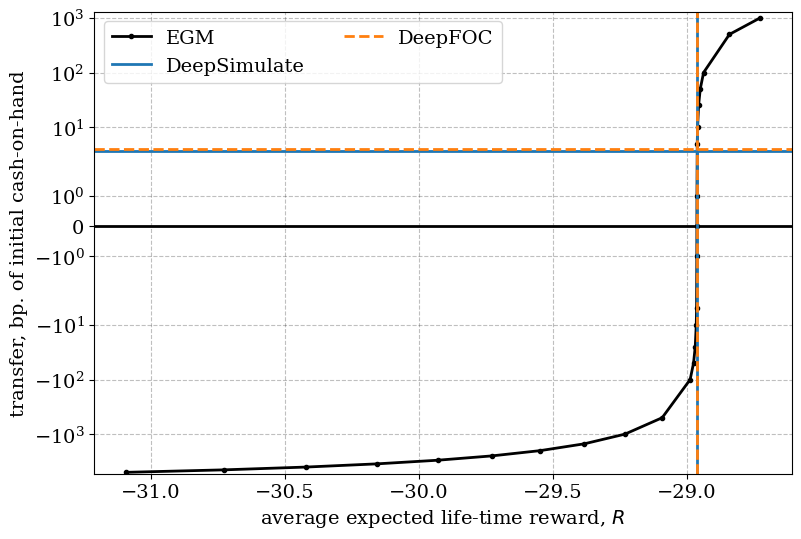

In [23]:
Ds = [1]
for D in Ds:
    transfer_plot('DurablesModel',models,algonames,D,folder=folder)

## 7. <a id='toc7_'></a>[Speed of Convergence](#toc4_2_)                   [&#8593;](#toc0_)

### 7.1. <a id='toc7_1_'></a>[With DP](#toc0_)

In [24]:
xlim = [0.1,1000]
ylim = [-1000,100]

1D rough


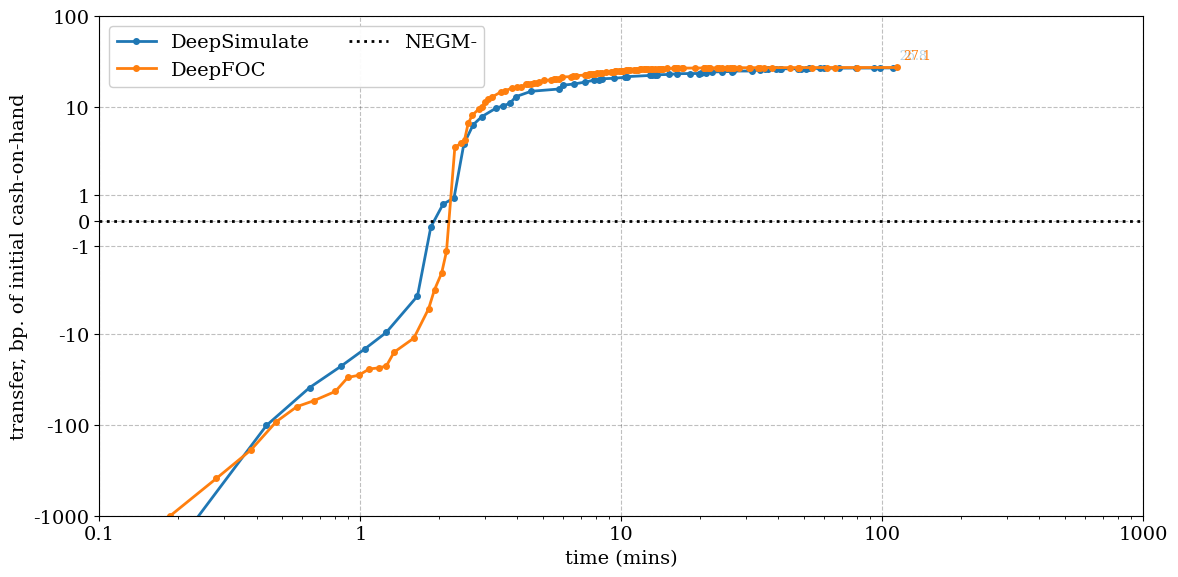

1D 


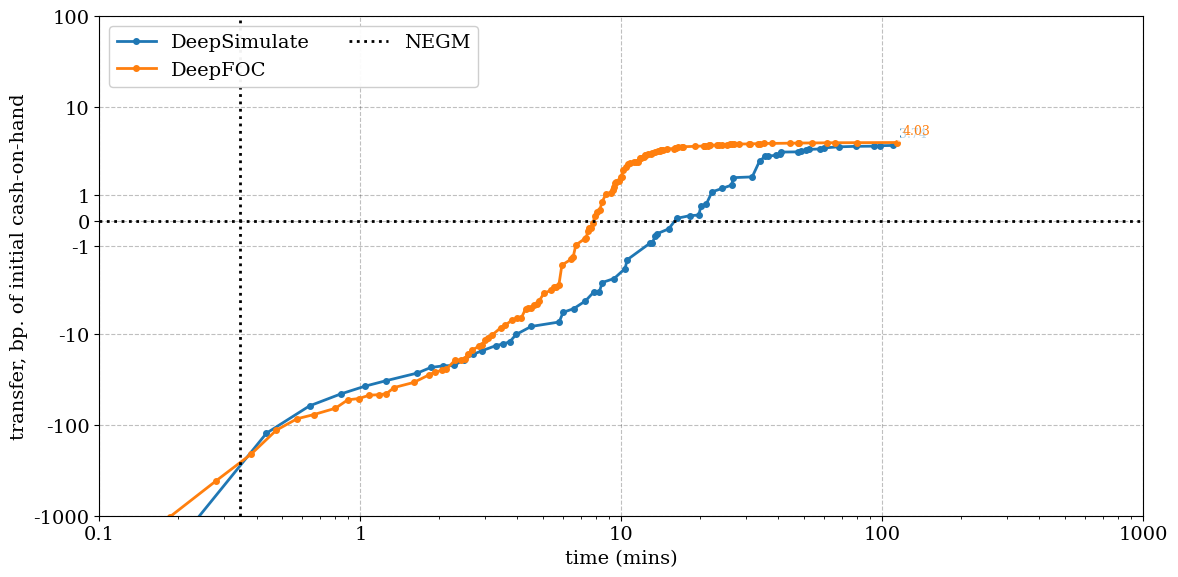

1D fine


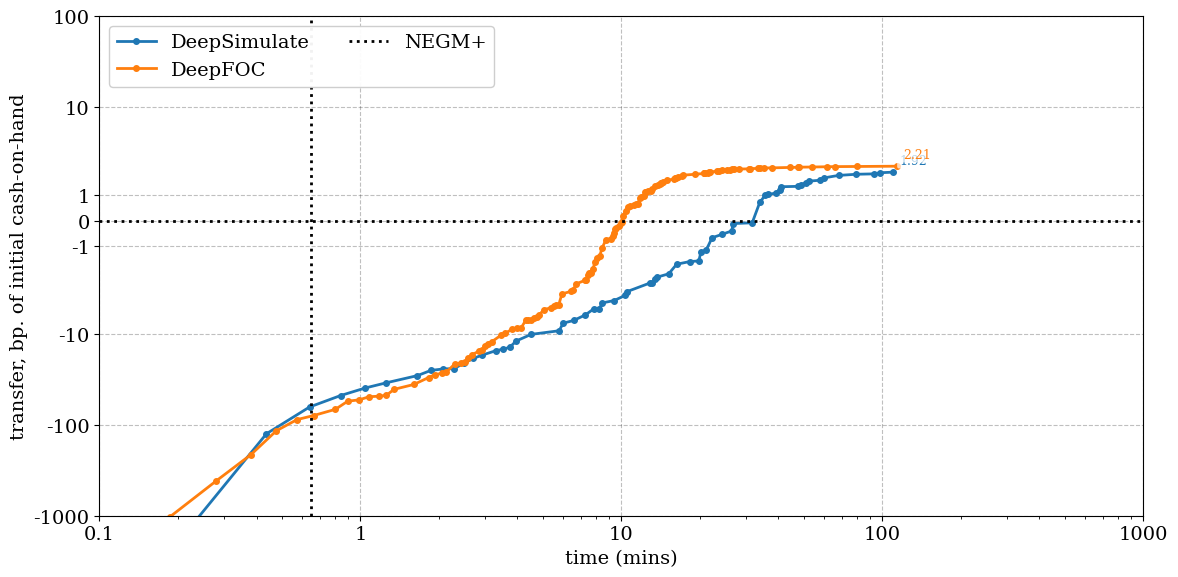

2D rough


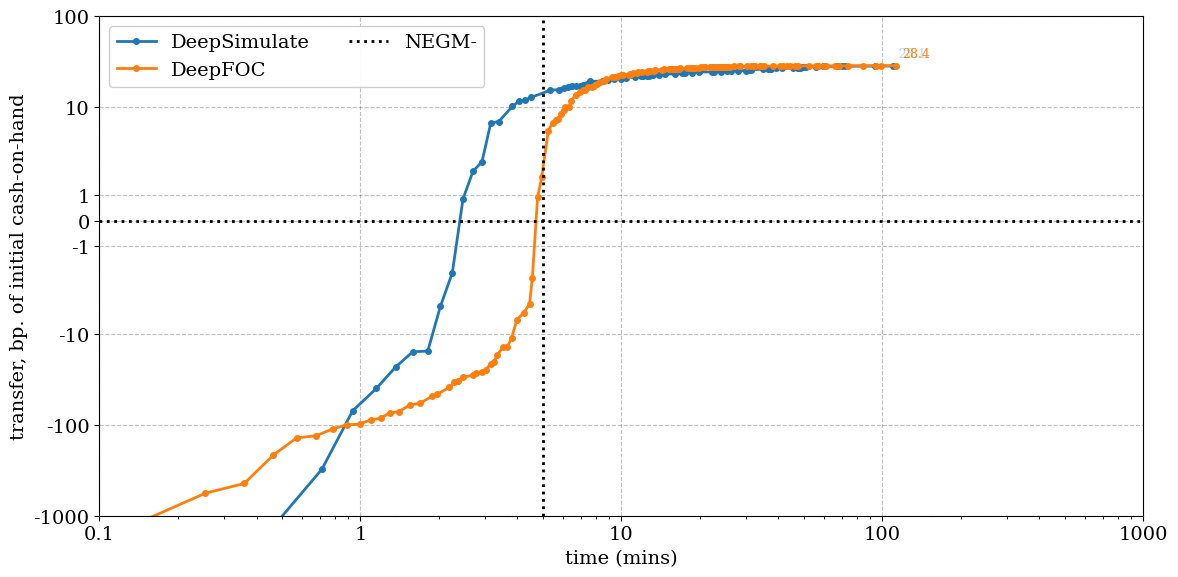

2D 


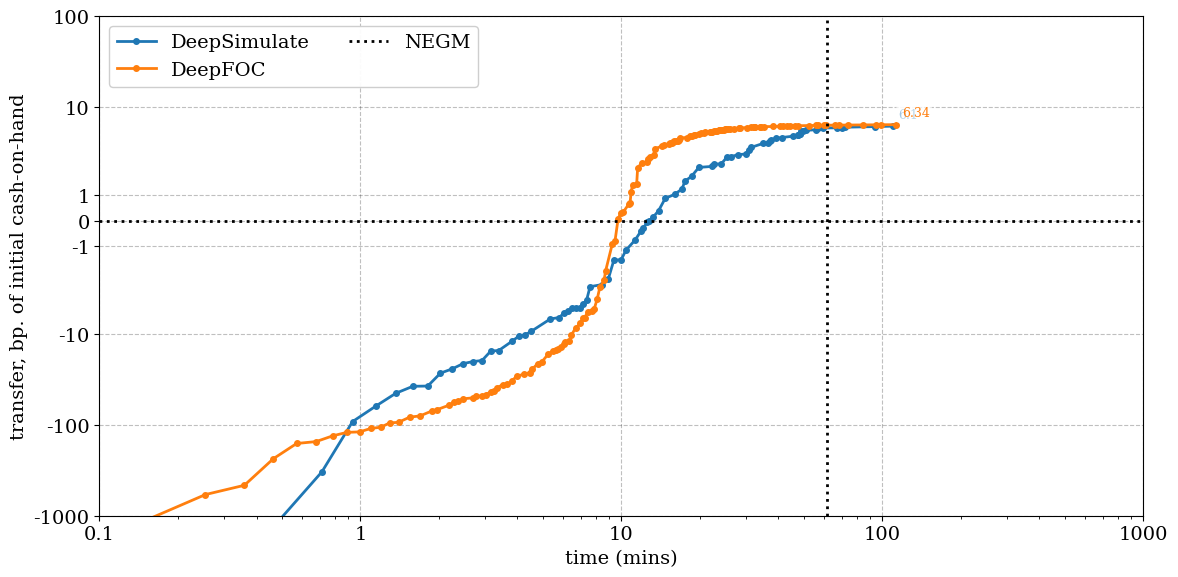

2D fine


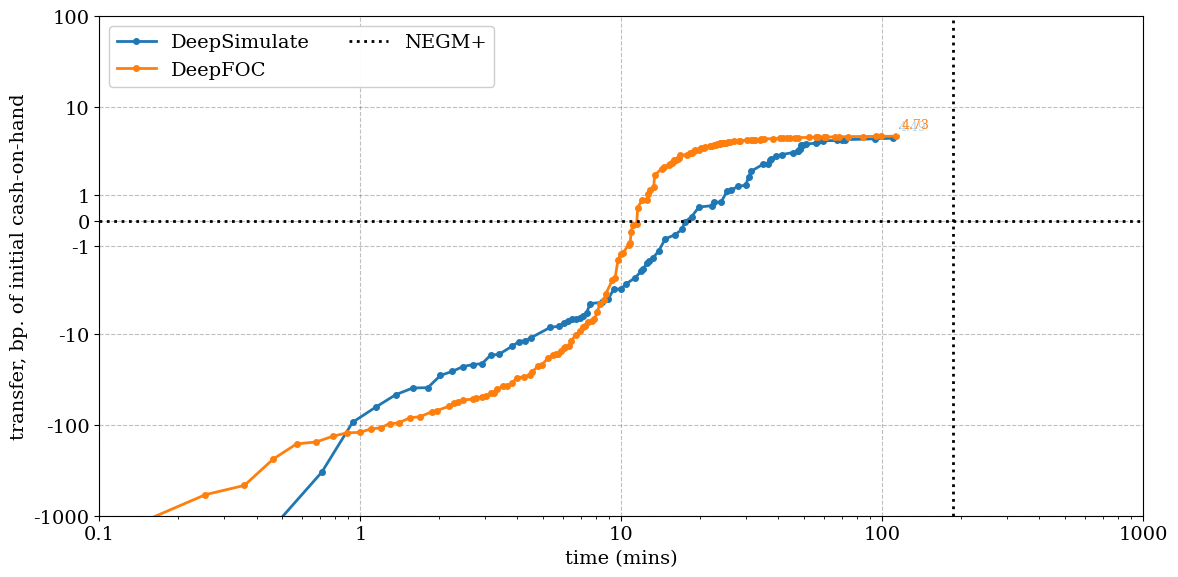

3D rough


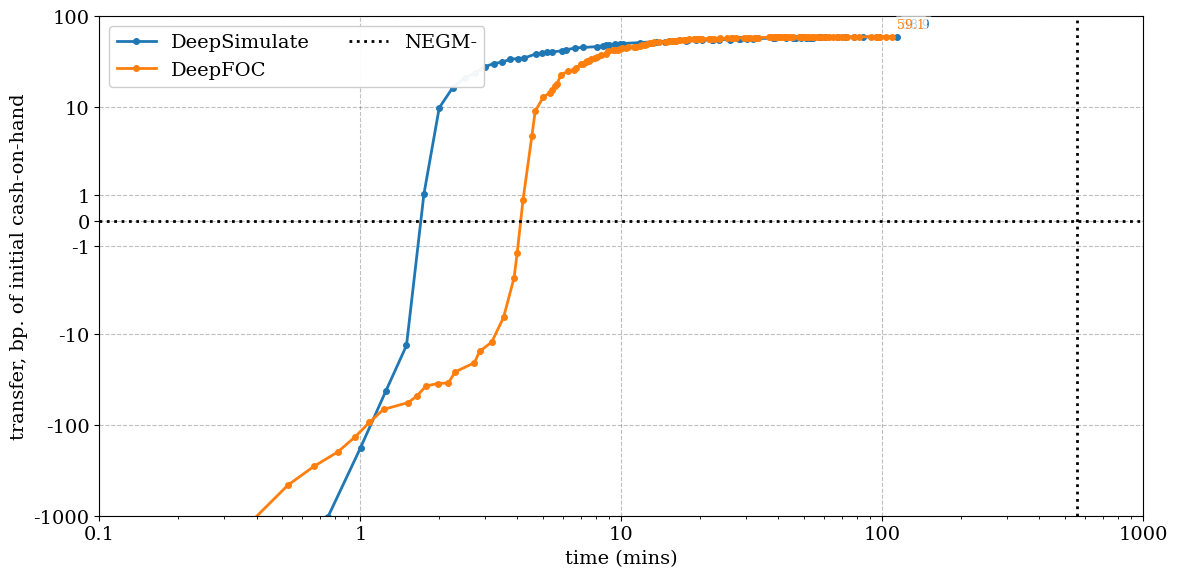

3D 
3D fine


In [25]:
for D in [1,2,3]:
    
    for DPstr in ['rough','','fine']:

        Dstr = f'{D}D'
        postfix = f'_{Dstr}'
        print(Dstr,DPstr)

        if DPstr == '': 
            if  ('DP',Dstr) not in models: continue
            DP = models[('DP',Dstr)]
        else:
            if  ('DP',Dstr,DPstr) not in models: continue
            DP = models[('DP',Dstr,DPstr)]

        if DPstr == 'fine':
            DP_name = '+'
        elif DPstr == 'rough':
            DP_name = '-'
        else:
            DP_name = ''

        if not DPstr == '': postfix += f'_{DPstr}'

        specs = {(algoname,Dstr):algolabels[algoname] for algoname in algonames}

        convergence_plot('DurablesModel',models,specs,DP=DP,do_transfer=True,DP_name=f'NEGM{DP_name}',
                            xlim=xlim,ylim=ylim,folder=folder,postfix=postfix)  

### 7.2. <a id='toc7_2_'></a>[Without DP](#toc0_)

8D


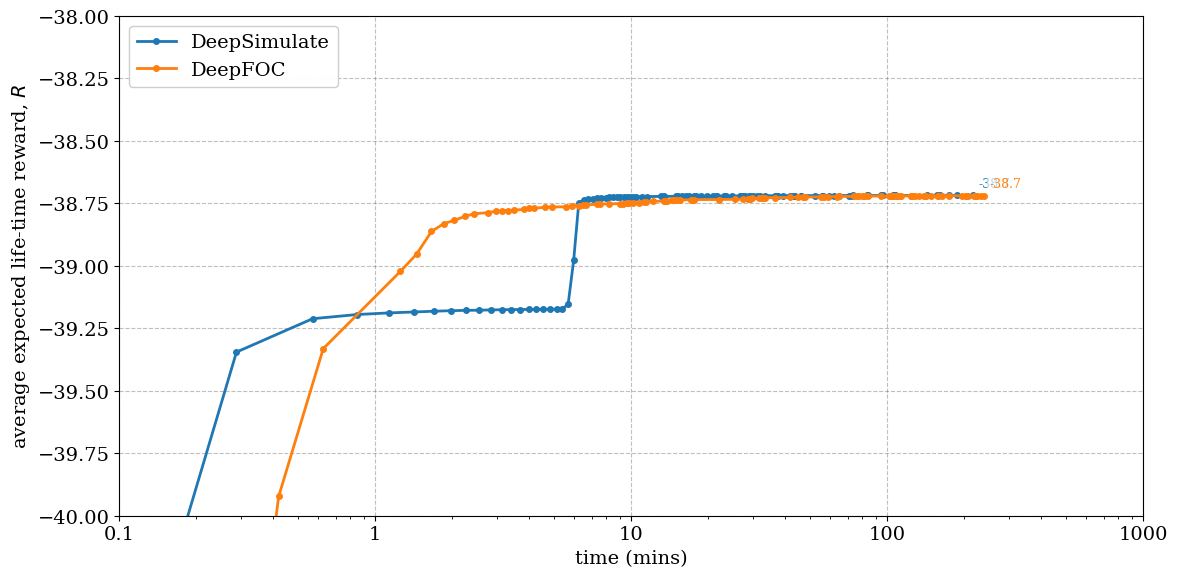

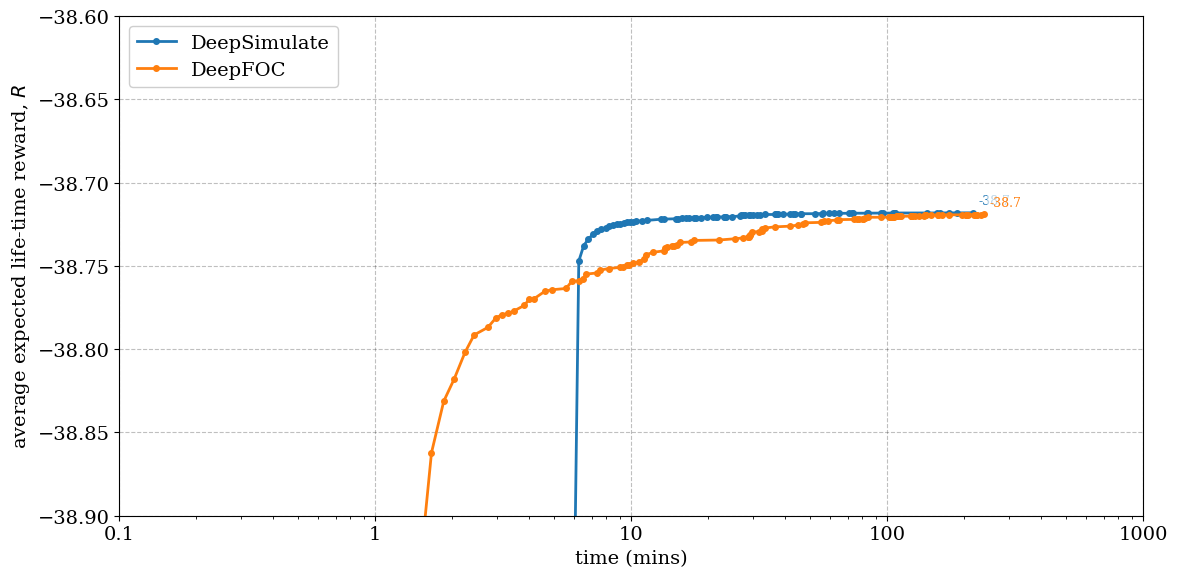

In [26]:
Ds = [8]
ylim = [-40,-38]
for D in Ds:
    
    Dstr = f'{D}D'
    print(Dstr)

    specs = {(algoname,Dstr):algolabels[algoname] for algoname in algonames}

    convergence_plot('DurablesModel',models,specs,DP=None,do_transfer=False,DP_name='NEGM',
                     xlim=xlim,ylim=ylim,legend_ncol=1,
                     folder=folder,postfix=f'_{Dstr}')
    
    convergence_plot('DurablesModel',models,specs,DP=None,do_transfer=False,
                     xlim=xlim,ylim=[-38.9,-38.60],legend_ncol=1,
                     folder=folder,postfix=f'_{Dstr}_zoom')         

#### 7.2.1. <a id='toc7_2_1_'></a>[Backward refinement](#toc0_)

In [27]:
D = 8 
backward = {}
for algoname in ['DeepFOC','DeepFOCBackward']:
    
    model = get_model(models,algoname,D)
    R = model.sim.R

    if algoname == 'DeepFOC':
        backward['t_beg'] = model.train.K_time
        backward['R_beg'] = R
    elif algoname == 'DeepFOCBackward':
        backward['R_end'] = R
        backward['t_end'] = backward['t_beg']+model.train.K_time

    print(f'{algoname:15s}: R = {R:.5f}')

DeepFOC        : R = -38.71915
DeepFOCBackward: R = -38.71904


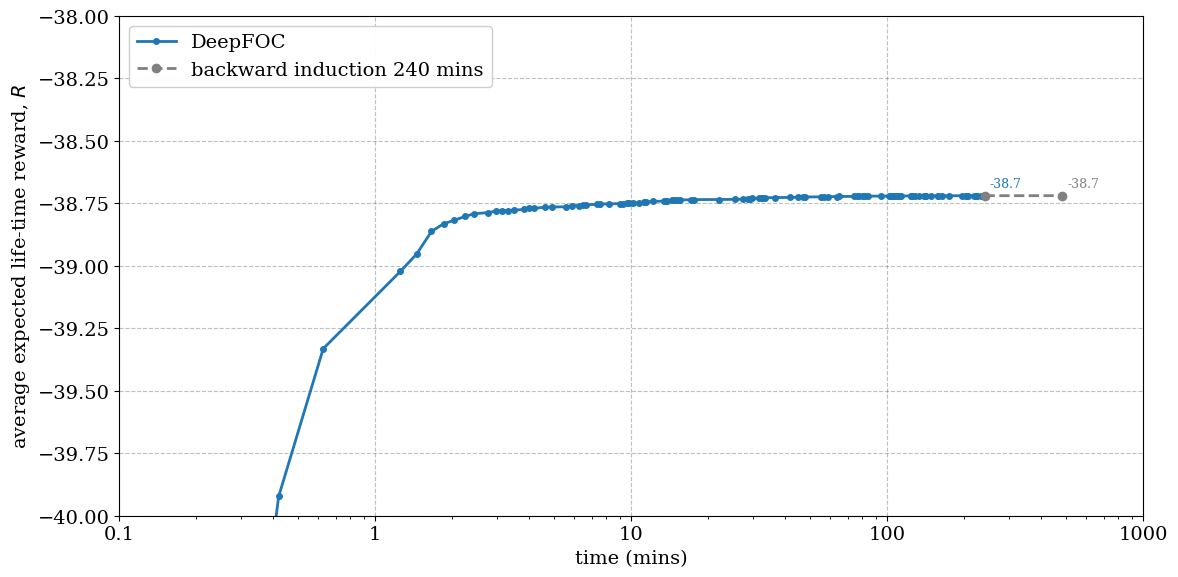

In [28]:
D = 8
algoname = 'DeepFOC'
xlim_low = [0.1,1000]

specs = {(algoname,f'{D}D'):f'{algoname}'}

convergence_plot('DurablesModel',models,specs,backward=backward,do_transfer=False,
                    xlim=xlim_low,ylim=ylim,legend_ncol=1,
                    folder=folder,postfix=f'_{D}D_{algoname}Backward_zoom')  

## 8. <a id='toc8_'></a>[(Consumption) Euler-errors](#toc0_)


In [29]:
def compute_mean_euler_DP(key,model):

    par = model.par
    savings_indicator = (model.sim.states_pd[:model.par.T_retired,:,0] > 1e-2)
    euler_error = model.sim.euler_error[:par.T_retired]
    euler_error = euler_error[savings_indicator]
    J = np.isclose(np.abs(euler_error),0.0)
    if (~J).sum() > 0 :
        model.info['euler_errors'] = np.log10(np.abs(euler_error[~J]))
        mean_euler_error = model.info['mean_euler_error'] = np.mean(model.info['euler_errors'])
    else:
        mean_euler_error = np.nan
    print(f'{str(key):40s} = {mean_euler_error:.2f} [{np.mean(J):.4f} share of euler errors are zero]')
    
for key,model in models.items():
    if 'Backward' in key: continue
    compute_mean_euler_DP(key,model)

('DP', '1D')                             = -3.51 [0.0000 share of euler errors are zero]
('DP', '1D', 'fine')                     = -3.83 [0.0000 share of euler errors are zero]
('DP', '1D', 'rough')                    = -2.79 [0.0000 share of euler errors are zero]
('DP', '2D')                             = -3.52 [0.0000 share of euler errors are zero]
('DP', '2D', 'fine')                     = -3.79 [0.0000 share of euler errors are zero]
('DP', '2D', 'rough')                    = -2.82 [0.0000 share of euler errors are zero]
('DP', '3D', 'rough')                    = -2.82 [0.0000 share of euler errors are zero]
('DeepFOCBackward', '8D')                = nan [1.0000 share of euler errors are zero]
('DeepFOC', '1D')                        = -3.88 [0.0001 share of euler errors are zero]
('DeepFOC', '2D')                        = -3.75 [0.0001 share of euler errors are zero]
('DeepFOC', '3D')                        = -3.62 [0.0001 share of euler errors are zero]
('DeepFOC', '8D')      

D = 1


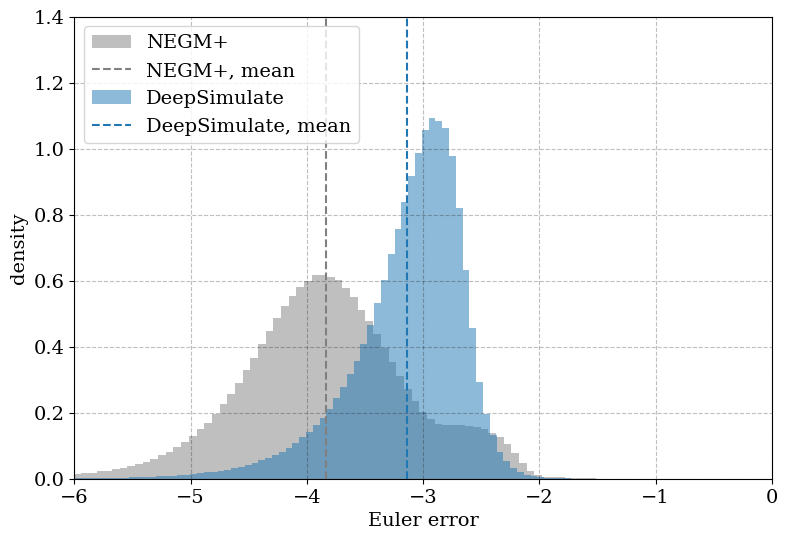

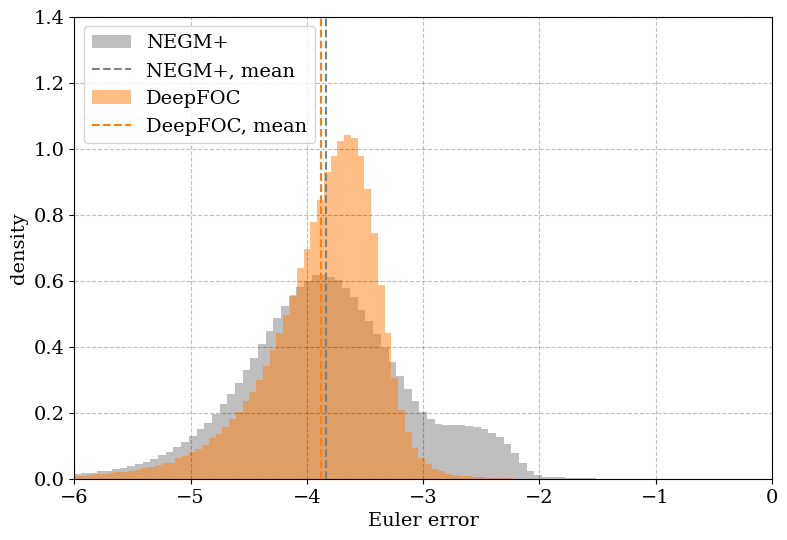

D = 2


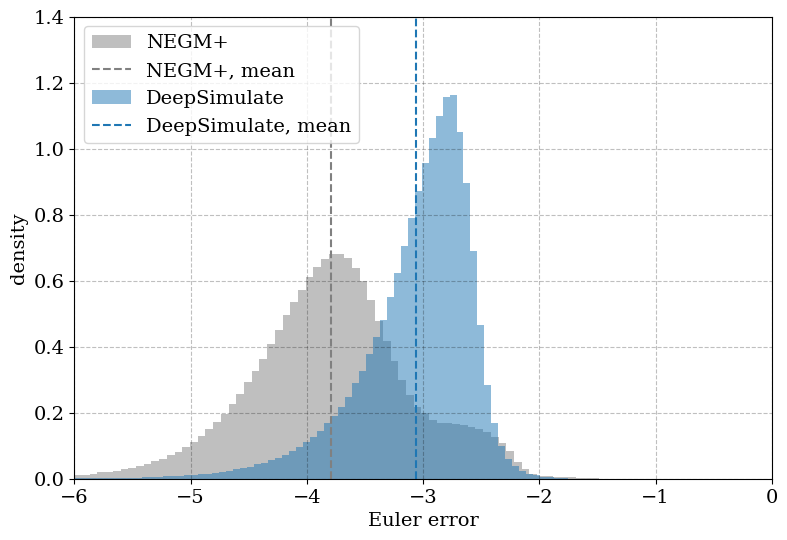

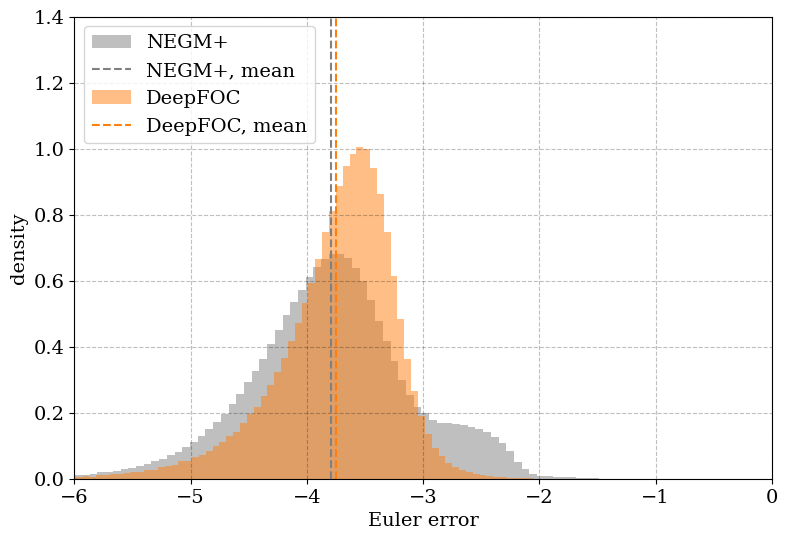

D = 3


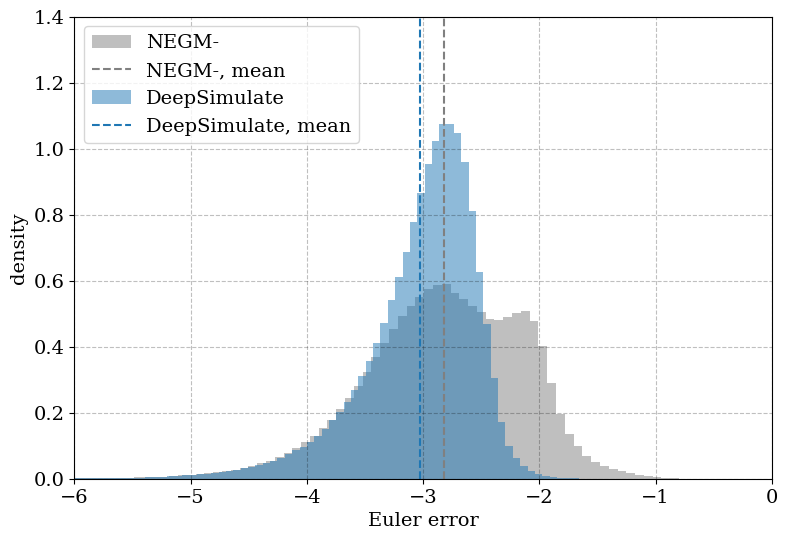

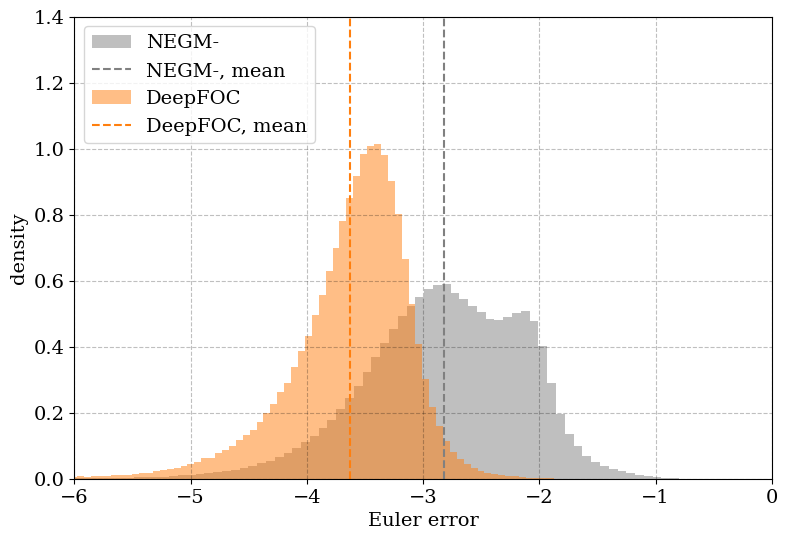

D = 8


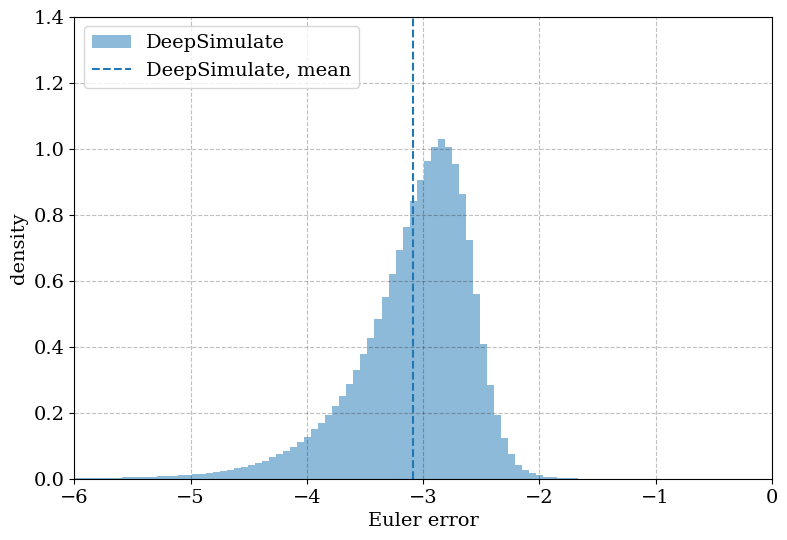

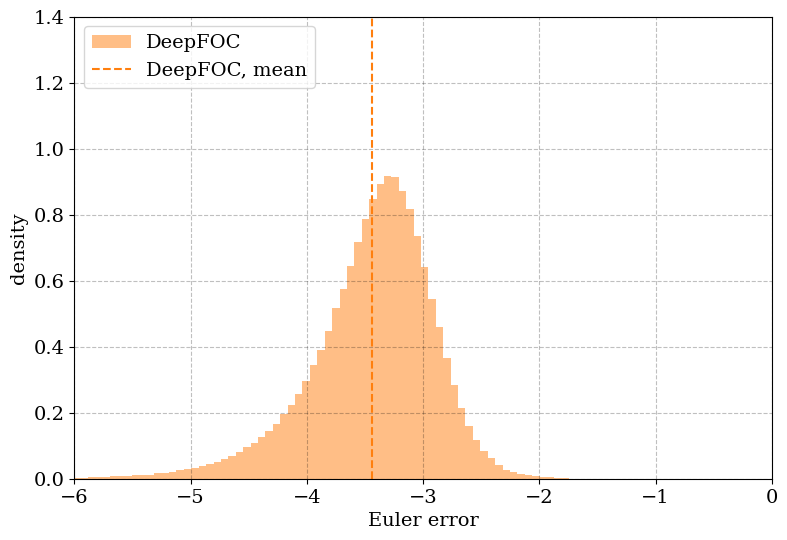

In [30]:
Ds = [1,2,3,8]
do_display = True

for D in Ds:
    print(f'{D = }')
    for i,algoname in enumerate(algonames):

        if D <= 3:
            DP = models[('DP',f'{D}D','fine')] if D < 3 else models[('DP',f'{D}D','rough')]
            _ = DP.info['euler_errors']
        else:
            DP = None

        label = algolabels[algoname]

        fig,ax = plt.subplots(1,1,figsize=(9,6))

        if not DP is None:
            
            egm_label = 'NEGM+' if D < 3 else 'NEGM-'

            ax.hist(DP.info['euler_errors'],bins=100,alpha=0.5,color='grey',density=True,label=egm_label)
            ax.axvline(x=DP.info['mean_euler_error'],color='grey',linestyle='--',label=egm_label+f', mean')   

        model = models[(f'{algoname}',f'{D}D')]
        ax.hist(model.info['euler_errors'],bins=100,alpha=0.5,color=colors[i],density=True,label=label)
        ax.axvline(x=model.info['mean_euler_error'],color=colors[i],linestyle='--',label=f'{label}, mean')
     
        ax.set_xlabel('Euler error')
        ax.set_ylabel('density')
        ax.set_xlim([-6,0])
        ax.set_ylim([0,1.4])
        ax.legend(loc='upper left')
        
        filepath = f"{folder}/DurablesModel_euler_error_{D}D_{algoname}.svg"
        fig.savefig(filepath,bbox_inches='tight')

        if do_display:
            plt.show()
        else:
            plt.close(fig)
            display(HTML(f'<a href="{filepath}">{filepath}</a>'))

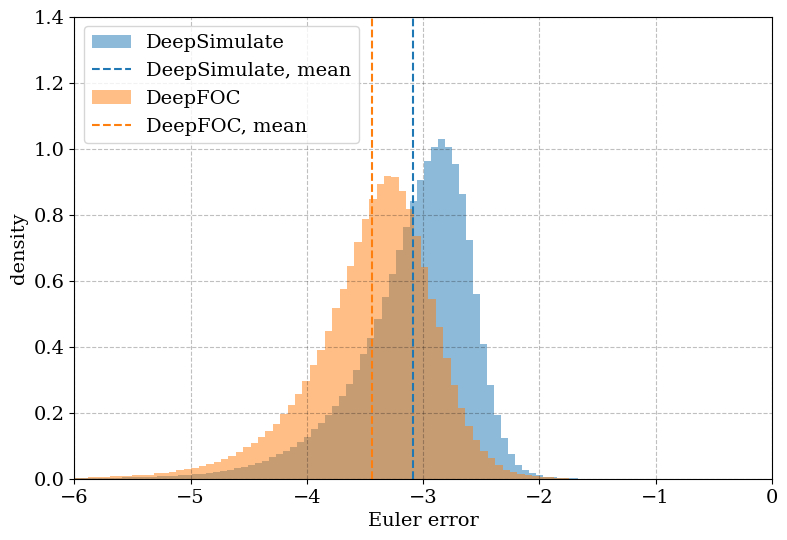

In [31]:
Ds = [8]
do_display = True

fig,ax = plt.subplots(1,1,figsize=(9,6))
for i,algoname in enumerate(algonames):

    model = models[(f'{algoname}',f'{D}D')]
    label = algolabels[algoname]
    ax.hist(model.info['euler_errors'],bins=100,alpha=0.5,color=colors[i],density=True,label=label)
    ax.axvline(x=model.info['mean_euler_error'],color=colors[i],linestyle='--',label=f'{label}, mean')
    
ax.set_xlabel('Euler error')
ax.set_ylabel('density')
ax.set_xlim([-6,0])
ax.set_ylim([0,1.4])
ax.legend(loc='upper left')

filepath = f"{folder}/DurablesModel_euler_error_{D}D.svg"
fig.savefig(filepath,bbox_inches='tight')

if do_display:
    plt.show()
else:
    plt.close(fig)
    display(HTML(f'<a href="{filepath}">{filepath}</a>'))

## 9. <a id='toc9_'></a>[Table](#toc0_)

### 9.1. <a id='toc9_1_'></a>[DP](#toc0_)

In [32]:
def create_table_DP(models,labels):

    # a. define column and row titles
    columns = labels    
    rows = [
        '$R$', 
        'Euler-error', 
        '',
        'Time (m)', 
        '',
        'Nn', 
        'Nm', 
        'Np', 
        'Nm-pd', 
        'Nm (keep)', 
        '',
        'GB', 
    ]

    # b. create with NaN values
    df = pd.DataFrame(index=rows,columns=columns).fillna('-')
    for col in columns:
        df.loc['',col] = ''

    # c. fill in values
    for model,label in zip(models,labels):
        df.loc['$R$',label] = f"{model.sim.R:.4f}"
        if 'mean_euler_error' in model.info:
            df.loc['Euler-error',label] = f"{model.info['mean_euler_error']:.2f}"
        df.loc['Time (m)',label] = f"{model.info['time']/60:.2f}"
        for key in ['Nn','Nm','Np','Nm_pd','Nm_keep']:
            if key == 'Nm_keep':
                df.loc['Nm (keep)',label] = model.egm.Nm_keep
            elif key == 'Nm_pd':
                df.loc['Nm-pd',label] = model.egm.Nm_pd
            else:
                df.loc[key,label] = model.egm.__dict__[key]
        df.loc['GB',label] = f"{model.info['memory_usage']:.2f}"

    return df

In [33]:
# a. select
models_DP = []
labels = []
for D in [1,2,3]:

    models_DP.append(models[('DP',f'{D}D','rough')])
    labels.append(f'{D}D-')    

    try:
        models_DP.append(models[('DP',f'{D}D')])
        labels.append(f'{D}D')
    except Exception:
        pass

    try:
        models_DP.append(models[('DP',f'{D}D','fine')])
        labels.append(f'{D}D+')
    except Exception:
        pass

# b. table
df = create_table_DP(models_DP,labels)
display(df)

# c.save
filename = f'{folder}/DurablesModel_table_DP.tex'
df.style.to_latex(filename,hrules=True)  

,1D-,1D,1D+,2D-,2D,2D+,3D-
$R$,-28.9671,-28.9614,-28.9609,-32.9017,-32.8954,-32.8949,-35.1819
Euler-error,-2.79,-3.51,-3.83,-2.82,-3.52,-3.79,-2.82
,,,,,,,
Time (m),0.07,0.35,0.64,5.03,61.37,187.24,556.94
,,,,,,,
Nn,50,100,150,50,100,150,50
Nm,50,100,150,50,100,150,50
Np,50,100,100,50,100,100,50
Nm-pd,300,300,300,300,300,300,300
Nm (keep),300,300,300,300,300,300,300


### 9.2. <a id='toc9_2_'></a>[Full](#toc0_)

In [34]:
def create_table(models,labels,DP=None,DP_name='NEGM'):

    # define column and row titles
    columns = [DP_name] + labels
    
    rows = [
        'Life-time reward, $R$', 
        'Transfer (bp.)', 
        'Mean log10 Euler error', 
        '',
        'Total time (m)', 
        '\\,\\,\\,training sample', 
        '\\,\\,\\,update NN', 
        '\\,\\,\\,validation',
        'Episodes', 
        'Avg. policy epochs', 
    ]

    # create with NaN values
    df = pd.DataFrame(index=rows,columns=columns).fillna('-')  # using '-' to represent missing df for display purposes
    for col in columns: df.loc['',col] = ''

    do_DP = DP is not None

    if do_DP: df.loc['Life-time reward, $R$', DP_name] = f'{DP.sim.R:.4f}'
    for model,label in zip(models,labels):
       df.loc['Life-time reward, $R$', label] = f"{model.sim.R:.4f}"

    if do_DP:

        df.loc['Transfer (bp.)', DP_name] = 0
        for model,label in zip(models,labels):

            model = model
            
            R = model.sim.R
            R_transfer = deepcopy(DP.sim.R_transfer)
            transfer = compute_transfer(R_transfer,DP.egm.transfer_grid,R,do_extrap=False)
            transfer_mean = transfer
            
            if not np.isnan(transfer_mean):
                df.loc['Transfer (bp.)', label] = f"{100**2*transfer_mean:.0f}"
            else:
                df.loc['Transfer (bp.)', label] = '-'

    if do_DP: df.loc['Mean log10 Euler error', DP_name] = f"{DP.info['mean_euler_error']:.2f}"
    for model,label in zip(models,labels):
        model = model
        df.loc['Mean log10 Euler error', label] = f"{model.info['mean_euler_error']:.2f}"
    
    if do_DP: df.loc['Total time (m)', DP_name] = f"{DP.info['time']/60:.2f}"
    for model,label in zip(models,labels):
        df.loc['Total time (m)', label] = f"{model.info['time']/60:.2f}"

    df.loc['\\,\\,\\,training sample',DP_name] = '-'
    for model,label in zip(models,labels):
        time_rel = model.info['time._simulate_training_sample'] / model.info['time']
        df.loc['\\,\\,\\,training sample', label] = f"{100*time_rel:.1f}\\%"

    df.loc['\\,\\,\\,update NN',DP_name] = '-'
    for model,label in zip(models,labels):
        time_rel = model.info['time.update_NN'] / model.info['time']
        df.loc['\\,\\,\\,update NN',label] = f"{100*time_rel:.1f}\\%"

    df.loc['\\,\\,\\,validation',DP_name] = '-'
    for model,label in zip(models,labels):
        time_rel = model.info['time.update_best'] / model.info['time']
        df.loc['\\,\\,\\,validation', label] = f"{100*time_rel:.1f}\\%"   

    df.loc['Episodes', DP_name] = '-'
    for model,label in zip(models,labels):
        df.loc['Episodes', label] = model.info['iter']

    df.loc['Avg. policy epochs', DP_name] = '-'
    for model,label in zip(models,labels):
        df.loc['Avg. policy epochs', label] = f"{model.info[('policy_epochs','mean')]:.1f}"

    return df

In [35]:
for D in [1,2,3,8]:

    print(f'{D = }')
    if D == 1:
        DP = models[('DP',f'{D}D','fine')]
        DP_name = 'NEGM+'
    elif D == 2:
        DP = models[('DP',f'{D}D','fine')]
        DP_name = 'NEGM+'
    elif D == 3:
        DP = models[('DP',f'{D}D','rough')]
        DP_name = 'NEGM-'
    else:
        DP = None
        DP_name = 'NEGM'

    models_ = [models[(algoname,f'{D}D')] for algoname in algonames]
    labels = [algolabels[algoname] for algoname in algonames]

    df = create_table(models_,labels,DP=DP,DP_name=DP_name)
    display(df)

    filename = f'{folder}/DurablesModel_table_{D}D.tex'
    df.style.to_latex(filename,hrules=True)  

    if D == 8:

        print('softmax:')

        models_ = [models[(algoname,f'{D}D','softmax')] for algoname in algonames]
        labels = [algolabels[algoname] for algoname in algonames]

        df = create_table(models_,labels,DP=DP,DP_name=DP_name)
        display(df)

        filename = f'{folder}/DurablesModel_table_{D}D_softmax.tex'
        df.style.to_latex(filename,hrules=True)  


D = 1


,NEGM+,DeepSimulate,DeepFOC
"Life-time reward, $R$",-28.9609,-28.9604,-28.9603
Transfer (bp.),0,2,2
Mean log10 Euler error,-3.83,-3.14,-3.88
,,,
Total time (m),0.64,120.01,120.01
"\,\,\,training sample",-,0.9\%,7.0\%
"\,\,\,update NN",-,96.1\%,78.5\%
"\,\,\,validation",-,2.4\%,13.1\%
Episodes,-,32245,25328
Avg. policy epochs,-,1.0,13.5


D = 2


,NEGM+,DeepSimulate,DeepFOC
"Life-time reward, $R$",-32.8949,-32.8937,-32.8936
Transfer (bp.),0,4,5
Mean log10 Euler error,-3.79,-3.06,-3.75
,,,
Total time (m),187.24,120.01,120.01
"\,\,\,training sample",-,0.7\%,7.0\%
"\,\,\,update NN",-,96.0\%,79.1\%
"\,\,\,validation",-,2.7\%,12.5\%
Episodes,-,28634,21641
Avg. policy epochs,-,1.0,13.2


D = 3


,NEGM-,DeepSimulate,DeepFOC
"Life-time reward, $R$",-35.1819,-35.1639,-35.1638
Transfer (bp.),0,59,59
Mean log10 Euler error,-2.82,-3.03,-3.62
,,,
Total time (m),556.94,120.01,120.01
"\,\,\,training sample",-,0.7\%,13.6\%
"\,\,\,update NN",-,96.2\%,75.4\%
"\,\,\,validation",-,2.6\%,10.0\%
Episodes,-,26556,14036
Avg. policy epochs,-,1.0,12.9


D = 8


,NEGM,DeepSimulate,DeepFOC
"Life-time reward, $R$",-,-38.7182,-38.7192
Transfer (bp.),-,-,-
Mean log10 Euler error,-,-3.09,-3.44
,,,
Total time (m),-,240.01,240.02
"\,\,\,training sample",-,0.6\%,14.3\%
"\,\,\,update NN",-,96.8\%,77.5\%
"\,\,\,validation",-,2.2\%,7.6\%
Episodes,-,46643,18756
Avg. policy epochs,-,1.0,13.0


softmax:


,NEGM,DeepSimulate,DeepFOC
"Life-time reward, $R$",-,-38.7183,-38.7182
Transfer (bp.),-,-,-
Mean log10 Euler error,-,-2.97,-3.30
,,,
Total time (m),-,240.01,240.01
"\,\,\,training sample",-,0.6\%,10.5\%
"\,\,\,update NN",-,97.0\%,76.1\%
"\,\,\,validation",-,1.9\%,12.8\%
Episodes,-,47359,19544
Avg. policy epochs,-,1.0,12.3


## 10. <a id='toc10_'></a>[Policy functions](#toc0_)


### 10.1. <a id='toc10_1_'></a>[1D](#toc0_)

#### 10.1.1. <a id='toc10_1_1_'></a>[Chose where to plot policy](#toc0_)


In [36]:
t = 5
means = np.mean(models[('DeepSimulate','1D')].sim.states,axis=1)

# find index in gid closest to mean of p and n
p_index = np.argmin(np.abs(models[('DP','1D')].egm.p_grid - means[t,1]))
n_index = np.argmin(np.abs(models[('DP','1D')].egm.n_grid - means[t,2]))

#### 10.1.2. <a id='toc10_1_2_'></a>[Generate policies in levels](#toc0_)

In [37]:
# GET DL POLICY FUNCTION AT CHOSEN POINTS

algoname = 'DeepSimulate'

# create model to get policy function
par_dict = {'T':models[(algoname,'1D')].par.T,'D':models[(algoname,'1D')].par.D,'KKT':algoname=='DeepFOC','full':True}
train_dict = {'Nneurons_policy':models[(algoname,'1D')].train.Nneurons_policy}
model = DurablesModelClass(algoname = algoname,par=par_dict,train=train_dict,device='cpu')
model.par.nu = models[(algoname,'1D')].par.nu

# load weights
model.policy_NN.load_state_dict(models[(algoname,'1D')].policy_NN)

# create state-tensor to compute policy on
state_tensor = torch.zeros((models[('DP','1D')].egm.Nm,model.par.Nstates),requires_grad=False)
state_tensor[:,0] = torch.tensor(models[('DP','1D')].egm.m_grid,requires_grad=False)
state_tensor[:,1] = models[('DP','1D')].egm.p_grid[p_index]
state_tensor[:,2] = models[('DP','1D')].egm.n_grid[n_index]

# compute policy at these points
policy = model.eval_policy(model.policy_NN,state_tensor,t=t)

#  convert policy to levels
# c,d,a = compute_d_and_c_from_action(model.par,state_tensor,policy)
c,d,a = compute_d_and_c_from_action(model.par,state_tensor,policy)
c = c.detach().numpy()
d = d.detach().numpy()

In [38]:
def d_consume_all(tau,m,epsilon):
	""" Computation maximum investment level if the consumer spend all cash-on-hand except for epsilon """

	if tau == 0.0:
	
		Delta_max = m - epsilon # if no adjustment cost problem is linear
	
	else:

		a = (-tau)
		b = -1
		c = m - epsilon
		denominator = 2*a
		numerator = (-b - (b**2-4*a*c)**(1/2))
		Delta_max = numerator/denominator

	return Delta_max

def adj_cost(par,Delta):
	""" Adjustment cost """

	return par.nu * (Delta)**2

def compute_d_and_c_from_action_DP(par,state,action,eps=None):
	""" Compute c,d,m_pd from state and action"""

	# a. make array for d
	array_shape =  state.shape[:-1] + (par.D,)
	if type(state) is np.ndarray:
		array_shape =  state.shape[:-1] + (par.D,)
		d_array = np.zeros(array_shape)
	else:
		d_array = torch.zeros(array_shape,dtype=state.dtype,device=state.device)

	# b. loop over durables to get durable choices
	mbar = 0.0 # initialize
	for i_d in range(par.D):

		# i. compute bounds
		d_low = 0.0
		if par.nonnegative_investment:
			d_low = state[...,2+i_d]
		
		if i_d == 0:
			mbar = state[...,0]

		d_high = state[...,2+i_d] + d_consume_all(par.tau,mbar,0.0)

		# ii. add noise to action if needed
		if eps is None:
			action_d = action[...,1+i_d]
		else:
			if type(state) is np.ndarray:
				action_d = np.clip(action[...,1+i_d]+eps[...,1+i_d],0,0.9999)
			else:
				action_d = torch.clamp(action[...,1+i_d]+eps[...,1+i_d],0,0.9999)
		
		# iii. compute durable consumption
		d = d_low+(d_high-d_low)*action_d

		# iv. store durable consumption
		d_array[...,i_d] = d

		# v. compute wealth after durable consumption
		Delta_d = d - state[...,2+i_d]
		mbar = mbar - Delta_d - adj_cost(par,Delta_d)
	
	# c. compute consumption
	if eps is None:
		action_c = action[...,0]
	else:
		if type(state) is np.ndarray:
			action_c = np.clip(action[...,0] + eps[...,0],0,0.9999)
		else:
			action_c = torch.clamp(action[...,0] + eps[...,0],0,0.9999)

	c = mbar*(1-action_c)

	# e. compute a from c
	m_pd = mbar - c

	return c,d_array,m_pd

In [39]:
# get policy functions
a_policy = models[('DP','1D')].egm.sol_m_pd_fac[t,p_index,n_index]
d_policy = models[('DP','1D')].egm.sol_d1_fac[t,p_index,n_index]

# map policies into same structure as NN_policies
actions = np.zeros((models[('DP','1D')].egm.Nm,2))
actions[:,0] = a_policy
actions[:,1] = d_policy
state_np = state_tensor.numpy()

# get policies in levels
models[('DP','1D')].par.tau = models[('DP','1D')].par.nu 
c_dp,d_dp,m_pd_dp = compute_d_and_c_from_action_DP(models[('DP','1D')].par,state_np,actions)

#### 10.1.3. <a id='toc10_1_3_'></a>[Plot](#toc0_)

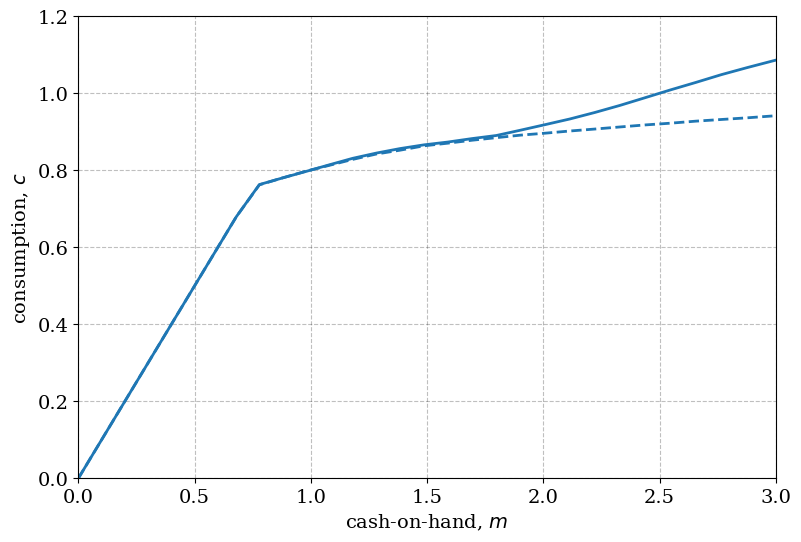

In [40]:
# create figure
fig, ax = plt.subplots(1,1,figsize=(9,6))

# plot policy
ax.plot(models[('DP','1D')].egm.m_grid,c,label='sell',color=colors[0],lw=2)
ax.plot(models[('DP','1D')].egm.m_grid,c_dp,label='sell',color=colors[0],lw=2,ls='--')

ax.set_xlabel('cash-on-hand, $m$')
ax.set_ylabel('consumption, $c$')
ax.set_xlim([0,3])
ax.set_ylim([0.0,1.2])

filepath = f"{folder}/DurablesModel_c_policy_DeepSimulate_D1.svg"
fig.savefig(filepath,bbox_inches='tight')

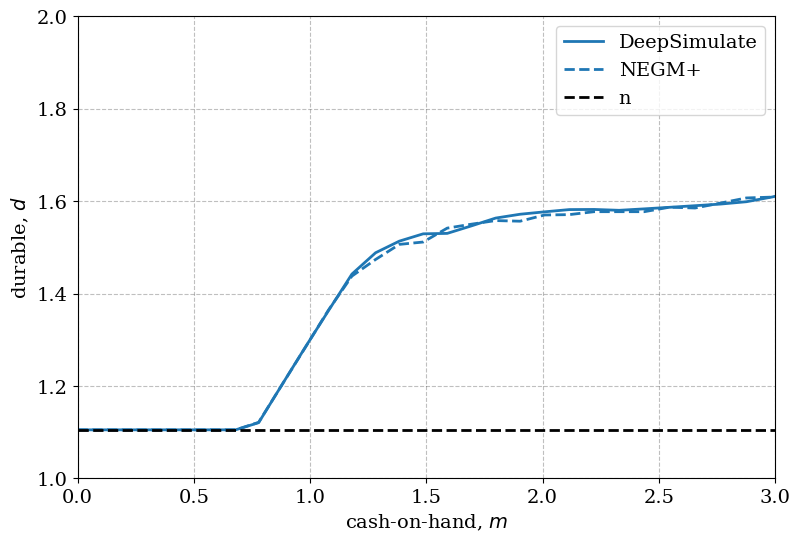

In [41]:
# create figure
fig, ax = plt.subplots(1,1,figsize=(9,6))

# plot policy
ax.plot(models[('DP','1D')].egm.m_grid,d,color=colors[0],lw=2, label='DeepSimulate')
ax.plot(models[('DP','1D')].egm.m_grid,d_dp,label='NEGM+',color=colors[0],lw=2,ls='--')

ax.set_xlabel('cash-on-hand, $m$')
ax.set_ylabel('durable, $d$')
ax.set_xlim([0,3])
ax.set_ylim([1.0,2.0])

# set hline at n_grid[n_index]
ax.axhline(models[('DP','1D')].egm.n_grid[n_index],lw=2,color='black',linestyle='--',label='n')

ax.legend()
filepath = f"{folder}/DurablesModel_d_policy_DeepSimulate_D1.svg"
fig.savefig(filepath,bbox_inches='tight')

### 10.2. <a id='toc10_2_'></a>[8D](#toc0_)

#### 10.2.1. <a id='toc10_2_1_'></a>[Choose where to plot policy](#toc0_)

In [42]:
t = 5
means = np.mean(models[('DeepSimulate','8D')].sim.states,axis=1)

Nm = 100
m_range = np.linspace(1e-8,3,Nm)

#### 10.2.2. <a id='toc10_2_2_'></a>[Get policy in levels](#toc0_)

In [43]:
algoname = 'DeepSimulate'

# create model to get policy function
par_dict = {'T':models[(algoname,'8D')].par.T,'D':models[(algoname,'8D')].par.D,'KKT':algoname=='DeepFOC','full':True} # 'use_softmax':True
train_dict = {'Nneurons_policy':models[(algoname,'8D')].train.Nneurons_policy}
model = DurablesModelClass(algoname = algoname,par=par_dict,train=train_dict,device='cpu')
model.par.nu = model.par.nu = models[(algoname,'8D')].par.nu

# load weights
model.policy_NN.load_state_dict(models[(algoname,'8D')].policy_NN)

# create state-tensor to compute policy on
state_tensor = torch.zeros((Nm,model.par.Nstates),requires_grad=False)
state_tensor[:,0] = torch.tensor(m_range,requires_grad=False)
state_tensor[:,1] = torch.tensor(means[t,1],requires_grad=False)
state_tensor[:,2:2+model.par.D] = torch.tensor(means[t,2:2+model.par.D],requires_grad=False)

# compute policy at these points
policy = model.eval_policy(model.policy_NN,state_tensor,t=t)

#  convert policy to levels
c,d,a = compute_d_and_c_from_action(model.par,state_tensor,policy)
c = c.detach().numpy()
d = d.detach().numpy()

#### 10.2.3. <a id='toc10_2_3_'></a>[Plot policy](#toc0_)

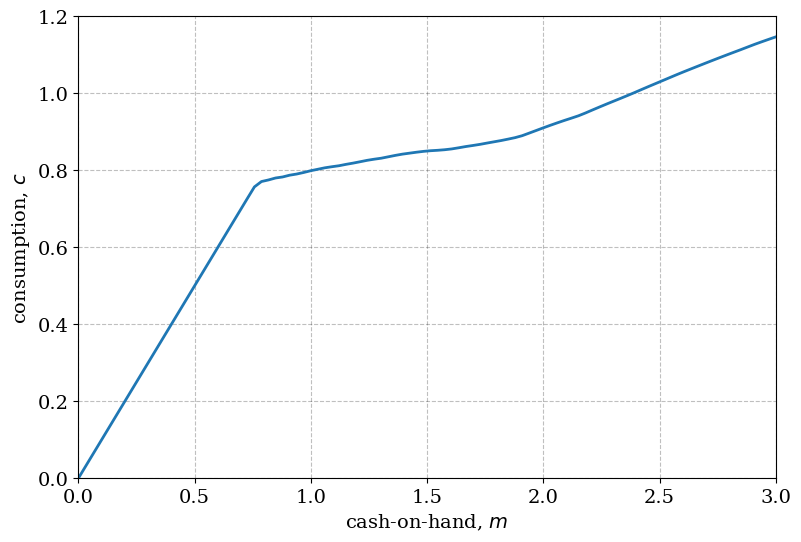

In [44]:
# create figure
fig, ax = plt.subplots(1,1,figsize=(9,6))

# plot policy
ax.plot(m_range,c,color=colors[0],lw=2)

ax.set_xlabel('cash-on-hand, $m$')
ax.set_ylabel('consumption, $c$')
ax.set_xlim([0,3])
ax.set_ylim([0.0,1.2])

filepath = f"{folder}/DurablesModel_c_policy_DeepSimulate_D8.svg"
fig.savefig(filepath,bbox_inches='tight')

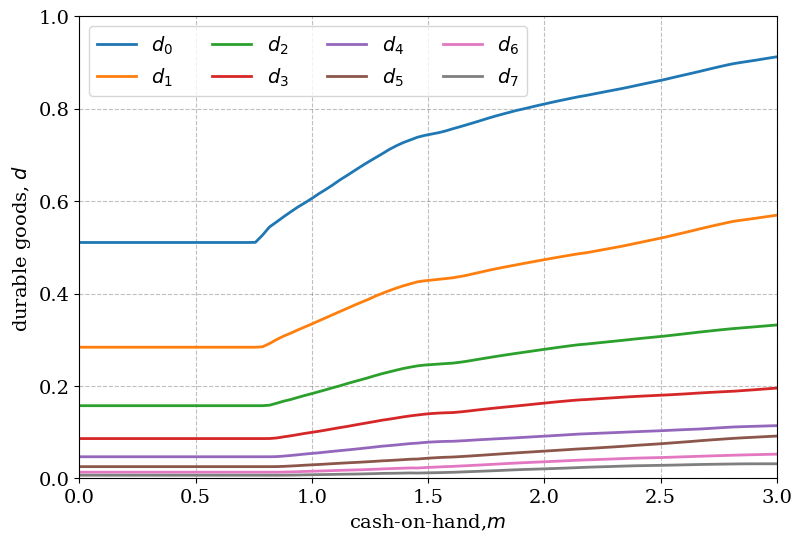

In [45]:
# create figure
fig, ax = plt.subplots(1,1,figsize=(9,6))

# plot policy
for i_d in range(model.par.D):
    ax.plot(m_range,d[:,i_d],label=f'$d_{i_d}$',color=colors[i_d],lw=2)

ax.set_xlabel('cash-on-hand,$m$')
ax.set_ylabel('durable goods, $d$')
ax.set_xlim([0,3])
ax.set_ylim([0.0,1.0])
ax.legend(ncol=4)

filepath = f"{folder}/DurablesModel_d_policy_DeepSimulate_D8.svg"
fig.savefig(filepath,bbox_inches='tight')

## 11. <a id='toc11_'></a>[More on convergence](#toc0_)

**Transfer in DeepSimulate:**

In [46]:
sim_base = deepcopy(model.sim)

In [47]:
pos = np.array([])
neg = np.array([1,5,10,20,50,100,500,1000])
transfer_grid = np.concatenate((-np.flip(neg),np.zeros(1),pos))/10_000
R_transfer = np.zeros(transfer_grid.size)

for i,transfer in enumerate(transfer_grid):

    model.sim = deepcopy(sim_base)
    model.sim.states[0,:,0] += transfer
    model.simulate_R()
    R_transfer[i] = model.sim.R

    print(f'transfer = {transfer*10_000:-7.0f}, R = {R_transfer[i]:8.4f}')

transfer =   -1000, R = -39.0794
transfer =    -500, R = -38.8926
transfer =    -100, R = -38.7521
transfer =     -50, R = -38.7351
transfer =     -20, R = -38.7249
transfer =     -10, R = -38.7215
transfer =      -5, R = -38.7198
transfer =      -1, R = -38.7185
transfer =       0, R = -38.7182


**Mimic DP:**

In [48]:
from types import SimpleNamespace
model.sim = sim_base
model.simulate_R()
model.egm = SimpleNamespace()
model.egm.transfer_grid = transfer_grid
model.sim.R_transfer = R_transfer

**Convergence plot:**

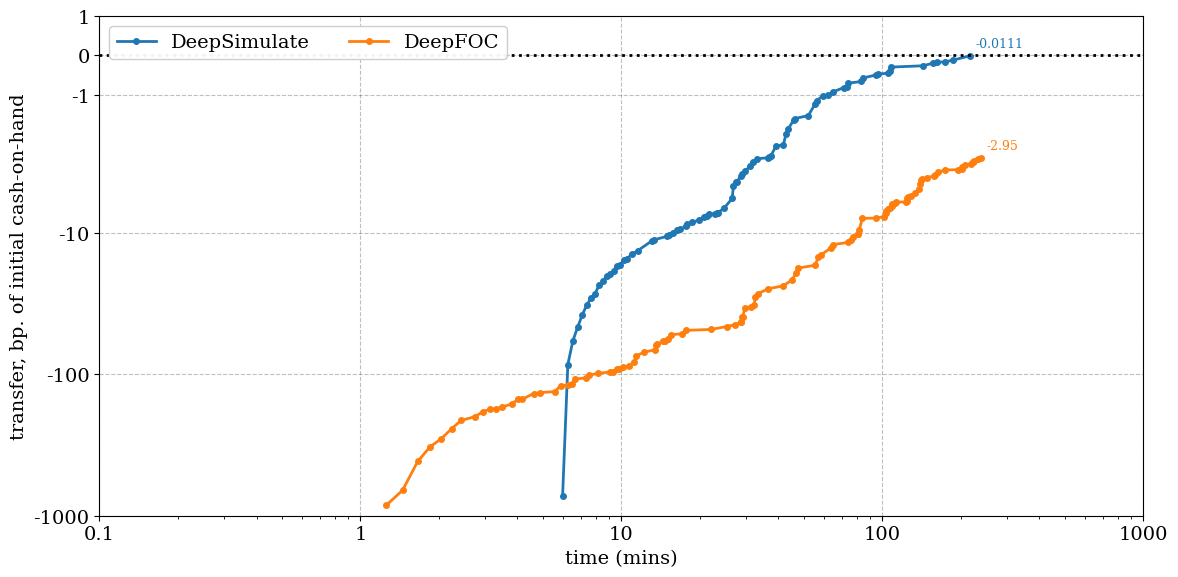

In [49]:
D = 8
Dstr = f'{D}D'
specs = {(algoname,Dstr):algolabels[algoname] for algoname in algonames}
convergence_plot('DurablesModel',models,specs,DP=model,do_transfer=True,
                    xlim=xlim,ylim=[None,1],
                    folder=folder,postfix=f'_{Dstr}_transfer_zoom')

### 11.1. <a id='toc11_1_'></a>[Backward](#toc0_)

In [50]:
D = 8 
backward = {}
for algoname in ['DeepFOC','DeepFOCBackward']:
    
    model_ = get_model(models,algoname,D)
    R = model_.sim.R

    transfer = compute_transfer(R_transfer,transfer_grid,R)    
    print(f'{algoname:25s}: R = {R:.5f} -> transfer = {100**2*transfer:.0f} bp.')

    if algoname == 'DeepFOC':
        backward['t_beg'] = model_.train.K_time
        backward['transfer_beg'] = transfer
    elif algoname == 'DeepFOCBackward':
        backward['transfer_end'] = transfer
        backward['t_end'] = backward['t_beg']+model_.train.K_time


DeepFOC                  : R = -38.71915 -> transfer = -3 bp.
DeepFOCBackward          : R = -38.71904 -> transfer = -3 bp.


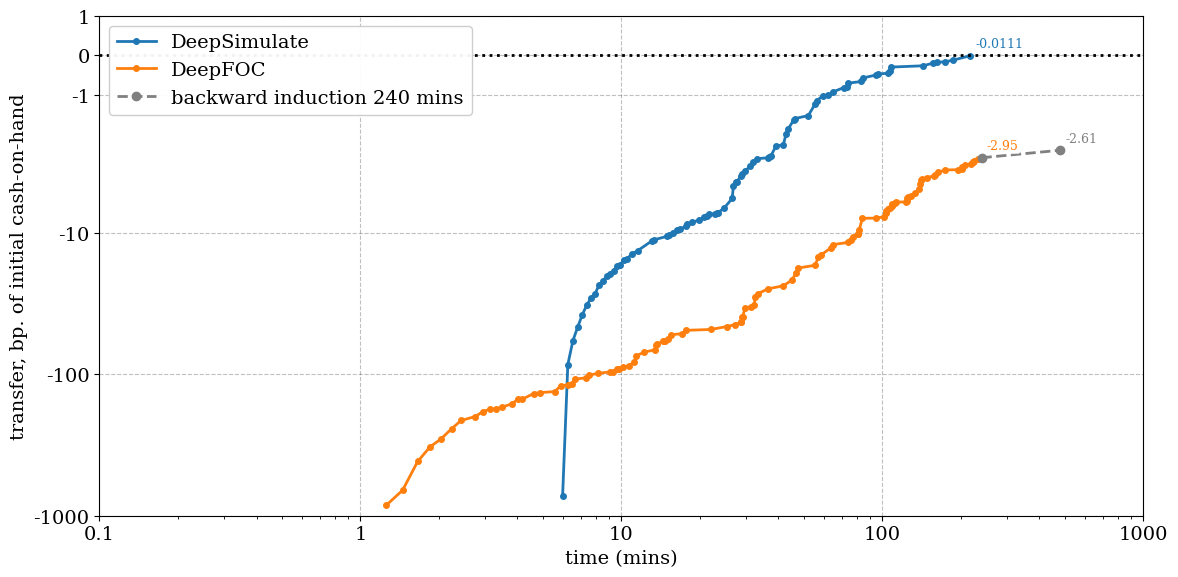

In [51]:
D = 8
algoname = 'DeepFOC'

specs = {(algoname,Dstr):algolabels[algoname] for algoname in algonames}
convergence_plot('DurablesModel',models,specs,backward=backward,DP=model,do_transfer=True,
                    xlim=xlim,ylim=[None,1],legend_ncol=1,
                    folder=folder,postfix=f'_{D}D_{algoname}Backward_transfer_zoom')  

### 11.2. <a id='toc11_2_'></a>[Softmax](#toc0_)

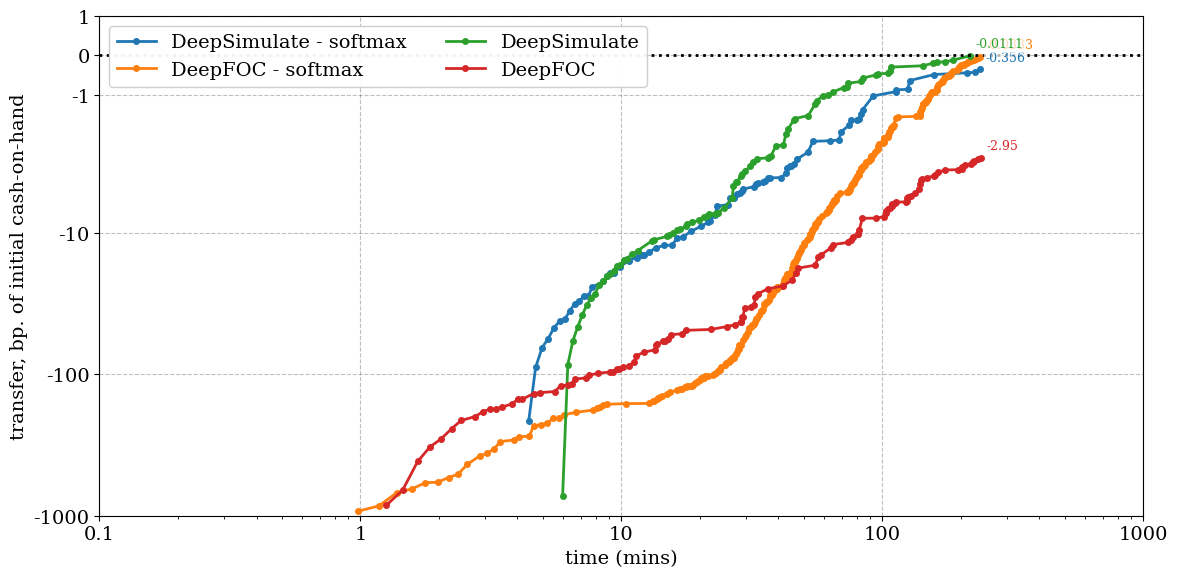

In [52]:
D = 8
Dstr = f'{D}D'
specs = {(algoname,Dstr,'softmax'): algolabels[algoname] + ' - softmax' for algoname in algonames}

for algoname in algonames:
    specs[(algoname,Dstr)] = algolabels[algoname]
convergence_plot('DurablesModel',models,specs,DP=model,do_transfer=True,
                    xlim=xlim,ylim=[None,1],
                    folder=folder,postfix=f'_{Dstr}_softmax_transfer_zoom')

## 12. <a id='toc12_'></a>[MPC, MPX](#toc0_)

DeepSimulate


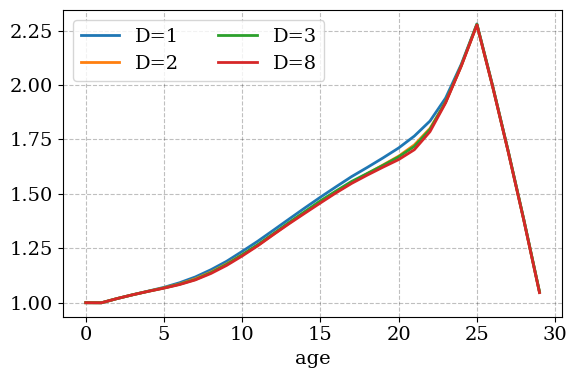

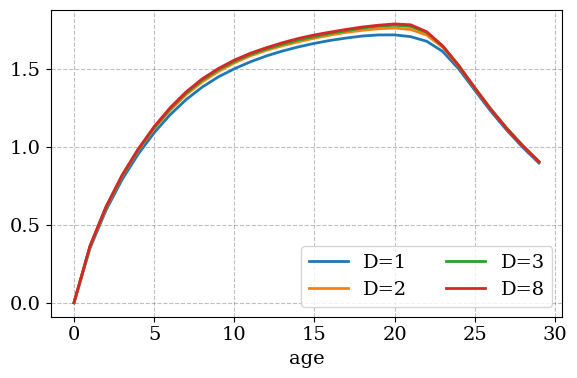

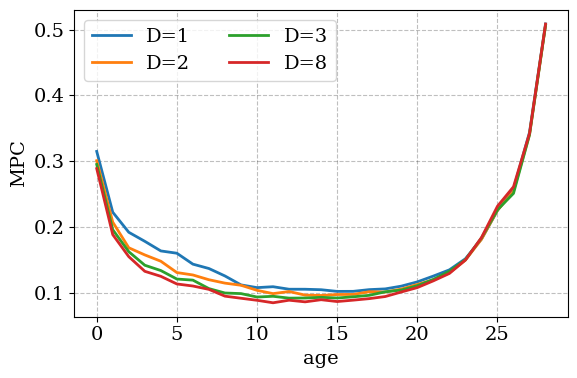

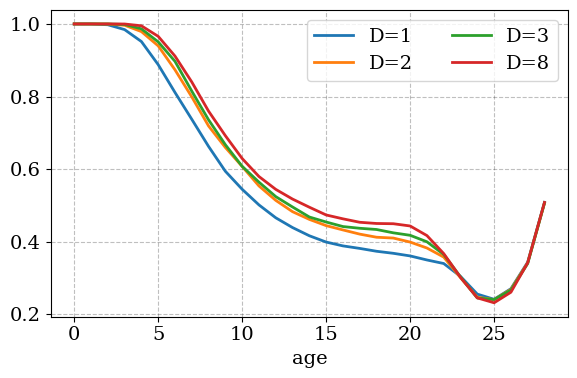

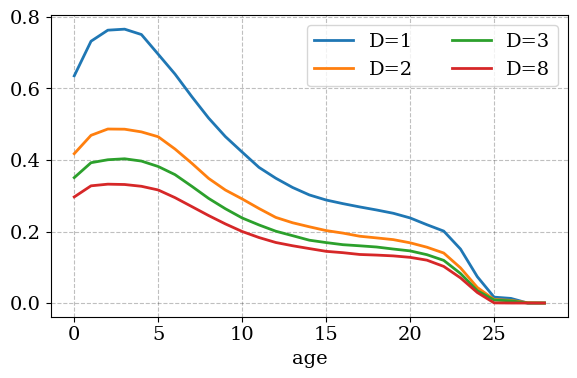

DeepFOC


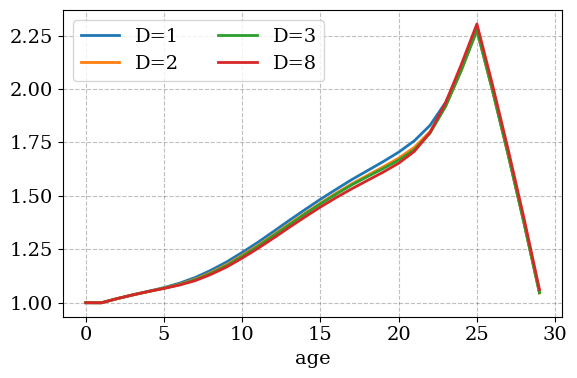

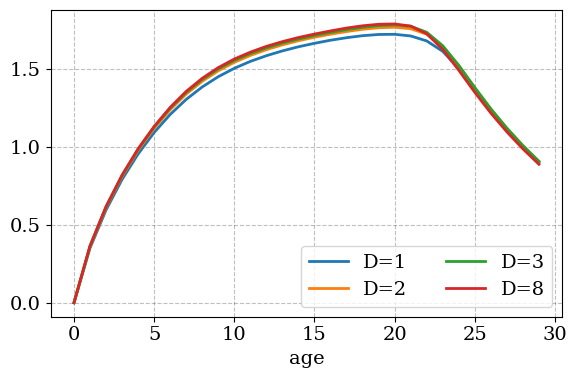

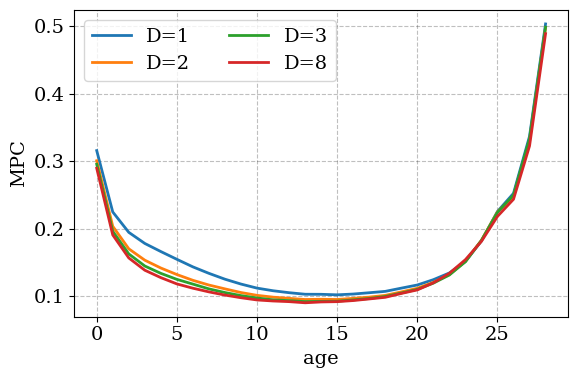

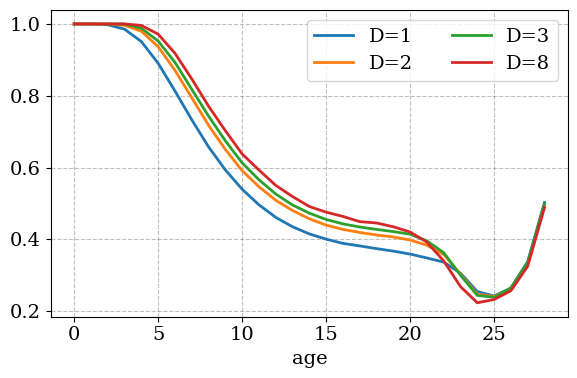

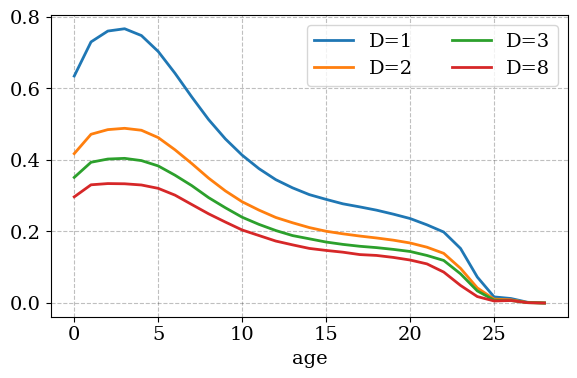

In [53]:
for algoname in algonames:

    print(algoname)
    Ds = [1,2,3,8]

    # cash-on-hand
    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(1,1,1)
    
    for i,D in enumerate(Ds):
        
        Dstr = f'{D}D'
        ax.plot(models[(algoname,Dstr)].sim.states[:,:,0].mean(axis=1),label=f'D={D}',color=colors[i],lw=2)

    ax.set_xlabel('age')
    ax.legend(ncol=2)

    fig.tight_layout()
    fig.savefig(f'{folder}/DurablesModel_lcp_m_{algoname}.svg')

    # durables
    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(1,1,1)
    
    for i,D in enumerate(Ds):
        
        Dstr = f'{D}D'
        ax.plot(models[(algoname,Dstr)].sim.states[:,:,2:].sum(axis=-1).mean(axis=1),label=f'D={D}',color=colors[i],lw=2)

    ax.set_xlabel('age')
    ax.legend(ncol=2)

    fig.tight_layout()
    fig.savefig(f'{folder}/DurablesModel_lcp_dsum_{algoname}.svg')

    # MPC on consumption
    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(1,1,1)
    
    for i,D in enumerate(Ds):
        
        Dstr = f'{D}D'
        ax.plot(models[(algoname,Dstr)].sim.MPC_c.mean(axis=1)[:-1], label=f'D={D}',color=colors[i],lw=2)

    ax.set_xlabel('age')
    ax.set_ylabel('MPC')
    ax.legend(ncol=2)

    fig.tight_layout()
    fig.savefig(f'{folder}/DurablesModel_lcp_MPC_c_{algoname}.svg')

    # MPX
    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(1,1,1)
    
    for i,D in enumerate(Ds):
        
        Dstr = f'{D}D'
        ax.plot(models[(algoname,Dstr)].sim.MPX.mean(axis=1)[:-1], label=f'D={D}',color=colors[i],lw=2)

    ax.set_xlabel('age')
    ax.legend(ncol=2)

    fig.tight_layout()
    fig.savefig(f'{folder}/DurablesModel_lcp_MPX_{algoname}.svg')

    # MPC_d0
    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(1,1,1)
    
    for i,D in enumerate(Ds):
        
        Dstr = f'{D}D'
        ax.plot(models[(algoname,Dstr)].sim.MPC_d[:,:,0].mean(axis=1)[:-1], label=f'D={D}',color=colors[i],lw=2)

    ax.set_xlabel('age')
    ax.legend(ncol=2)

    fig.tight_layout()
    fig.savefig(f'{folder}/DurablesModel_lcp_MPC_d0_{algoname}.svg')

    plt.show()